---
title: "Yagi and Kunii's effective conductivity: a sum of five mechanisms, and the one the data never switch on"
description: "The 1957 packed-bed conductivity model, separated into the three kinds of result the paper contains - theory, other people's data re-analysed, and the authors' own measurements - with a measurement of how much of it the tabulated data can actually test."
categories: [sec:A, struct:S6, tier:T0, data:tier2, phase:gas-solid]
date: 2026-08-05
---

# Yagi and Kunii's effective thermal conductivity

**Catalog ID:** `A3.12` · **Structures:** `S6` · **Tier:** T0

A packed bed conducts heat by several routes at once, and Yagi & Kunii's
contribution was to write them down as a sum instead of a fitted lump. Their
Equation (15) adds conduction through the solid, conduction through the thin film
of gas at the contact points, radiation from solid surface to solid surface,
radiation from void to void, and — once gas flows — lateral mixing. Each term
carries its own geometric factor, and the whole thing is still the skeleton of
every stagnant-conductivity correlation used today.

That structure sets the honest question for this page. **A sum of mechanisms is
only as good as the range over which each term has been exercised.** If every
number the model was checked against sits where one of the terms is negligible,
the coefficient in front of that term is not evidence-backed, and a reader has no
way to tell from the printed comparison. Section
[Which mechanisms the data actually exercise](#which-mechanisms-the-data-actually-exercise)
measures exactly that, and the answer is sharper than expected.

## Three kinds of result, kept apart

The paper's own abstract announces three distinct pieces of work, and the gallery
requires that **measurement** and **the authors' own computed output** never be
blurred. This paper needs a third label as well:

| | what it is | where | this page's label |
|---|---|---|---|
| **Theory** | Equations (1)–(19), derived from a seven-mechanism picture plus Ranz's lateral mixing | journal pages 374–376 | *reproduced* — re-derived and cross-checked against its own printed limits |
| **Other people's data, re-analysed** | Table 1 ($\alpha\beta$ from flow experiments) and Table 3 (20 rows of $k_e^0/k_g$, measured elsewhere, beside Yagi & Kunii's calculated value) | pages 373, 377 | *third-party measurement + the authors' reduction of it* |
| **The authors' own measurements** | air over iron spheres, porcelain, cement clinker, insulating firebrick, Raschig rings, 0–1000 °C | **Figures 13–17 only**, as plotted points | *scoped out* — see below |

The third row is the one that costs this page something. Yagi & Kunii's own
measurements exist **only as plotted points**; a footnote says the complete
tabular material was deposited as document 5305 with the American Documentation
Institute, and that deposit is not in hand. Extracting them would need a
figure digitisation and its maintainer review, and no maintainer is available, so
**the measured points in Figures 13–17 are not digitised and this page makes no
claim about them.**

What *is* printed for those beds is Table 4 — every parameter Equation (15)
needs — so the paper's own **calculated** curves can be reproduced, and several of
the conclusions the authors draw from those figures are stated in the text as
numbers and can be checked. That is what section [Results](#results) does. Two
things are read off the figures themselves, and both are deliberately narrow:

- the **ends of the smooth lines each of Figures 13–17 labels "THEORETICAL" or
  "CALCD."** — the authors' own computed output, not their data. Section
  [The curves the authors drew](#the-curves-the-authors-drew) compares them with
  Equation (15) evaluated here, which is the only quantitative evidence on this
  page about the emissivity the paper never prints.
- the **two endpoints of each of Figure 12's five temperature profiles**, which fix
  the temperature drop the apparatus actually ran. Nothing on this page uses that
  figure's interior markers or its unlabelled abscissa.

Reading a curve's ordinate off a labelled tick ladder is not the same act as
extracting a scatter of measured points, and the two datasets say so in their
sidecars.

**Ranz is cited, not consulted.** Equation (1), the lateral-mixing mechanism,
is attributed to Ranz, *Chem. Eng. Progr.* **48**, 247 (1952). That paper is not
on disk — the only Ranz item here is a one-page 1993 "Citation Classic"
reminiscence about Ranz & Marshall (1952), which carries no correlations at all.
Nothing about Ranz is written here from memory: every statement about Equation (1)
comes from what Yagi & Kunii themselves print.

In [1]:
# Colab: install pymrm if it is not already present.
try:
    import pymrm
except ImportError:
    %pip install -q pymrm

import sys, os
from pathlib import Path

# Make shared/gallery_utils.py importable both from a checkout and on Colab.
try:
    from gallery_utils import load_data, load_meta, cite_data, report_agreement
except ImportError:
    root = Path.cwd()
    for _ in range(4):
        if (root / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(root / "shared"))
            break
        root = root.parent
    else:
        import urllib.request
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")
    from gallery_utils import load_data, load_meta, cite_data, report_agreement

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy.optimize import brentq

from pymrm import construct_grad, construct_div, construct_coefficient_matrix

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
np.set_printoptions(linewidth=150)
PAGE = "A3.12-yagi-kunii-effective-conductivity"
METRICS = {}
print("pymrm", pymrm.__version__)

pymrm 2.3.1.dev3+g93eeaefb4


## Background

### Seven mechanisms, sorted into two groups

Yagi & Kunii's Figure 1 lists seven ways heat crosses a packed bed. They sort
them by whether fluid flow matters (journal page 374):

*Independent of fluid flow* — (1) conduction through the solid; (2) conduction
through the contact surfaces of two packings; (3) radiation between solid
surfaces; (4) radiation between neighbouring voids.

*Dependent on fluid flow* — (5) conduction through the fluid film near the
contact surface of two packings; (6) convection solid–fluid–solid;
(7) lateral mixing of fluid.

Two of those get argued away immediately, and the argument is worth keeping
because it is what makes the additive split legitimate. Mechanism 5 is analysed
on a two-dimensional model (their Figure 2) and found to carry nearly all its
heat through the thin film right at the contact point — interstices that "are
embedded in the boundary layers except in the case of large Reynolds number", so
flow barely touches it. Mechanism 6 is shown to be small at all Reynolds numbers.
So mechanisms 1–5 are lumped into a flow-independent $k_e^0$, mechanism 7 is
added in parallel, and mechanism 6 is dropped:

$$ k_e = k_e^0 + (k_e)_t . \tag{5} $$

### The flow term, from Ranz

Equation (1), attributed to Ranz, writes the lateral-mixing contribution as
$(k_e)_t = \alpha C_p G / N$, where $N$ is the number of solids per unit length
in the flow direction. With $\beta = l_p/D_p$ the ratio of centre-to-centre
spacing to particle diameter (Eq. 2) and $N = 1/\beta D_p$ (Eq. 3), that becomes

$$ \frac{(k_e)_t}{k_g} = (\alpha\beta)\,N_{Pr}N_{ReM} = (\alpha\beta)\,N_{PeM},
\qquad N_{ReM} = \frac{D_pG}{\mu},\quad N_{PeM} = \frac{D_pC_pG}{k_g}. \tag{4} $$

So the whole flow dependence collapses to a single slope $(\alpha\beta)$ against
the particle Péclet number, and the paper's Table 1 is nothing but that slope,
twenty rows of it, drawn from nine sources:

$$ \frac{k_e}{k_g} = \frac{k_e^0}{k_g} + (\alpha\beta)\,N_{PeM}. \tag{6} $$

Yagi & Kunii print two constraints on the constants: $\alpha = 0.179$ "in case of
the rhombohedral packing of spheres", and "in practical packed beds $\beta$ takes
a limited value between 0.82 and 1.0". Both are testable against Table 1, and
[Results](#results) does that.

### The static term

Radiation between two grey surfaces of emissivity $p$, and between two voids,
gets the Stefan–Boltzmann coefficient linearised about the local temperature:

$$ h_{rs} = 0.1952\,\frac{p}{2-p}\left(\frac{t+273}{100}\right)^{3}, \tag{7} $$

$$ h_{rv} = \frac{0.1952}{\,1 + \dfrac{\epsilon}{2(1-\epsilon)}\dfrac{1-p}{p}\,}
           \left(\frac{t+273}{100}\right)^{3}. \tag{8} $$

The prefactor is $4\sigma$ in the paper's units — kcal/(m² hr °C) with the
temperature group in hundreds of kelvin — so both coefficients reduce to the
black-body value $0.1952\,(T/100)^3$ at $p = 1$. **The paper never prints a value
of $p$.** Figure 3 describes the two surfaces bounding a void as "black body
surface A′" and "black body surface B′", so $p = 1$ is used throughout here, and
the sensitivity to that choice is measured in [Validation](#validation).

Assembling the resistances of Figure 4 — conduction along the solid in series
with the contact region, in parallel with void-to-void radiation — gives the
general result (their Eq. 13, with $\delta$ the fraction of area in perfect
solid–solid contact, $\gamma = l_s/D_p$ and $\varphi = l_v/D_p$):

$$ \frac{k_e^0}{k_g} = \delta\frac{k_s}{k_g}
 + \frac{(1-\epsilon-\delta)\beta}
        {\gamma\left(\dfrac{k_g}{k_s}\right)
         + \dfrac{1}{\dfrac{1}{\varphi} + \dfrac{D_p h_{rs}}{k_g}}}
 + \epsilon\beta\frac{D_p h_{rv}}{k_g}. \tag{13} $$

Analysing powder data under 0.05–0.20 mm Hg the authors find $\delta < 10^{-5}$,
so at atmospheric pressure $\delta$ drops out and Eq. (13) becomes the working
form:

$$ \boxed{\;\frac{k_e^0}{k_g} =
 \frac{\beta(1-\epsilon)}
      {\gamma\left(\dfrac{k_g}{k_s}\right)
       + \dfrac{1}{\dfrac{1}{\varphi} + \dfrac{D_p h_{rs}}{k_g}}}
 + \epsilon\beta\frac{D_p h_{rv}}{k_g}\;} \tag{15} $$

with two special cases printed beside it — the vacuum limit (Eq. 14) and, for
fine particles or liquid-filled voids where radiation is negligible,

$$ \frac{k_e^0}{k_g} = \beta\,\frac{1-\epsilon}{\dfrac{k_g}{k_s} + \varphi}. \tag{16} $$

Notice what is **not** in Eq. (15): there is no term for plain conduction through
the open void. The gas phase contributes only through the contact film (inside
$\varphi$) and through void-to-void radiation. That is a real modelling choice and
it is why $k_e^0/k_g$ can fall below unity — Table 3 has a row where it does.

### Reading the equations from the page image

Every equation above was read from a page render at the scan's native 300 ppi (see
[The data](#the-data)). The text layer of this 1957
Wiley scan destroys them: Eq. (8) comes back as `.b}]{(t P + 273)/100)3`, Eq. (13)
as `- ' k.= 6@ k,`, and Eq. (15) does not survive at all. Two printed identities
make the transcription checkable without trusting a single reading, and both are
run in [Validation](#validation): **Eq. (16) must be Eq. (15) with both radiation
coefficients set to zero and $\gamma = 1$**, and **Eq. (14) must be the
$k_g \to 0$ limit of Eq. (13)**. A mis-read term in the big equation breaks one or
both.

## The published model

The implementation below is a direct transcription. `h_rs`, `h_rv`, `eq15`,
`eq16` and `eq14` are the paper's Equations (7), (8), (15), (16) and (14); nothing
is fitted anywhere on this page.

In [2]:
SIG4 = 0.1952   # = 4*sigma in the paper's units: kcal/(m2 hr degC) per (T/100 K)^3


def h_rs(t_C, p=1.0):
    """Eq. (7): radiation coefficient, solid surface to solid surface."""
    return SIG4 * (p / (2.0 - p)) * ((t_C + 273.0) / 100.0) ** 3


def h_rv(t_C, eps, p=1.0):
    """Eq. (8): radiation coefficient, void to void."""
    return SIG4 / (1.0 + eps / (2.0 * (1.0 - eps)) * (1.0 - p) / p) \
        * ((t_C + 273.0) / 100.0) ** 3


def eq15(eps, beta, gamma, phi, Dp_m, ks, kg, hrs, hrv):
    """Eq. (15): ke0/kg for gas-filled voids. Dp in METRES (h_r is per m2)."""
    contact = 1.0 / ((1.0 / phi) + Dp_m * hrs / kg)     # film + solid-solid radiation
    solid_path = beta * (1.0 - eps) / (gamma * (kg / ks) + contact)
    void_rad = eps * beta * Dp_m * hrv / kg
    return solid_path + void_rad


def eq16(eps, beta, phi, ks, kg):
    """Eq. (16): the radiation-free form, for fine particles or liquid-filled voids."""
    return beta * (1.0 - eps) / ((kg / ks) + phi)


def eq14(eps, beta, Dp_m, ks, hrs, hrv, delta=0.0):
    """Eq. (14): the vacuum limit, normalised on ks rather than kg."""
    return delta + beta * (1.0 - eps) / (1.0 + ks / (Dp_m * hrs)) \
        + eps * beta * Dp_m * hrv / ks


def eq6(ke0_over_kg, alpha_beta, N_PeM):
    """Eq. (6): the static term plus Ranz's lateral mixing."""
    return ke0_over_kg + alpha_beta * N_PeM


print("Eq. (15) sanity, iron-sphere parameters at 400 degC:")
print(f"  {eq15(0.40, 1.0, 1.0, 0.034, 11.0e-3, 45.0, 0.0447, h_rs(400.0), h_rv(400.0, 0.40)):.3f}")

Eq. (15) sanity, iron-sphere parameters at 400 degC:
  31.181


## Parameters and assumptions

Everything Equation (15) needs, and where each piece comes from:

| symbol | meaning | source |
|---|---|---|
| $\epsilon$ | fraction void | printed per row in Tables 3 and 4 |
| $D_p$ | mean packing diameter | printed, in mm; converted to metres because $h_r$ is per m² |
| $k_s$ | solid conductivity | printed per row |
| $k_g$ | gas conductivity | **the paper's own printed table**, from Cowling, 0–1200 °C, linearly interpolated |
| $\beta$ | $l_p/D_p$, centre-to-centre spacing over diameter | 1 for ordinary packings; derived per case for Raschig rings |
| $\gamma$ | $l_s/D_p$, effective conduction length over diameter | 1 for ordinary packings; $1.2/9$ for the rings |
| $\varphi$ | $l_v/D_p$, effective film thickness over diameter | **Figures 9 and 10** — the one input that is not printed as a number, except through Table 4 |
| $p$ | emissivity | **never printed**; $p=1$ assumed, sensitivity measured |
| $\delta$ | perfect-contact area fraction | $<10^{-5}$ by the authors' own vacuum analysis; set to 0 |

Three of those need saying plainly.

**$\beta$ is printed twice for one bed.** Table 4's iron-sphere row gives "1.0 and
0.9", and Figure 13 draws a curve for each; the CSV carries the second as `beta_alt`.
Because $\beta$ scales Equation (15) uniformly, it cancels out of every *ratio* this
page reports, so no metric here distinguishes the two — except the curve-end check in
[The curves the authors drew](#the-curves-the-authors-drew), which reproduces both.

**$k_g$ is an input, not a detail.** Every quantity on this page is a ratio to
$k_g$, so using a modern air correlation instead of the seven values Yagi & Kunii
print would make the reproduction of their numbers depend on data they never had.
The page interpolates linearly between their printed points and nowhere else.

**$\varphi$ is the model's one free geometric parameter, and it lives in a
figure.** The text gives exactly one anchor — "according to curve B for cylinders
or spheres in Figure 9, the value of $\varphi$ is 0.034 for the fraction void
$\epsilon = 0.4$" — and Table 4 prints four $(\epsilon,\varphi)$ pairs its own
footnote attributes to that same line B. Those four pairs are used here as a
printed stand-in for the figure. Figure 9 itself is **not** digitised. This
matters more than it looks, and [Which mechanisms the data actually exercise](#which-mechanisms-the-data-actually-exercise)
is where it bites.

## The data

Four printed tables and two narrow readings off figures. None came from the text
layer, which interleaves the two-column body text with the tables and shuffles rows.

**On resolution.** `pdfimages -list` reports every page of this scan as a
2400 × 3299 CCITT-G4 bilevel image at **300 ppi native**. Rendering at 600 dpi —
which the first pass of this page did — is interpolation: it enlarges the image
without adding information. Every numeric quoted here has since been cropped and
re-read at the native 300 ppi, which is how the $\delta < 10^{-5}$ of the
[Background](#background) was corrected from a first reading of $10^{-6}$.

- **`yagi-kunii-1957-table1.csv`** — Table 1, page 373. Twenty rows of flow data
  from nine sources — eight of them other laboratories, the ninth the authors' own
  collaborators — each reduced by Yagi & Kunii to one slope $(\alpha\beta)$ and one
  intercept $k_e^0/k_g$.
- **`yagi-kunii-1957-table3.csv`** — Table 3, page 377. Twenty rows of measured
  $k_e^0/k_g$ from nine sources other than the authors' own experiments, beside
  Yagi & Kunii's own calculated value. **The only place in the paper where a measurement and a model prediction
  are printed side by side as numbers.**
- **`yagi-kunii-1957-table4.csv`** — Table 4, page 377. The authors' own packings
  and every parameter their calculated curves used.
- **`yagi-kunii-1957-air-conductivity.csv`** — the unnumbered $k_g(t)$ table under
  Table 3, attributed to Cowling.
- **`yagi-kunii-1957-figures13to17-curve-ends.csv`** — 17 readings of the ends of the
  authors' own **theoretical** curves in Figures 13–17. Their computed output, not
  their data.
- **`yagi-kunii-1957-figure12-endpoints.csv`** — the outside and inside temperature of
  each of Figure 12's five profiles, and nothing else from that figure.

No dataset from another gallery page is loaded, so the cross-page rule does not
apply here.

Three properties of these rows have to be carried into everything below, because
they are load-bearing:

1. **Three rows of Table 3 carry no printed `Exp.` value** (reference 4 at
   $D_p = 12$, reference 5 at 12.7, reference 15 at 16.5). Their temperature and
   voidage cells are blank because they repeat the row above, so whether the
   experimental cell repeats too is genuinely ambiguous. They are recorded as
   missing and excluded from every deviation statistic.
2. **Six rows carry no $D_p$** (an em dash). Both radiation coefficients enter
   Eq. (15) only through the group $D_p h_r / k_g$, so those rows cannot have been
   computed with Eq. (15) at all — they must be Eq. (16), which is exactly what the
   text says was used ("by means of Equation (15) or (16)").
3. **$\varphi$ is in neither table.** Every use of Table 3 below therefore either
   solves for the $\varphi$ each printed value implies, or takes $\varphi$ from
   Table 4's printed line.
4. **Table 3's `Exp.` column is footnoted.** Journal page 377 prints, under the
   table, *"\*Estimated values. †Extrapolated values, $N_{ReM} \to 0$."* Seven of
   the twenty rows carry the dagger and the CSV records them in `exp_extrapolated`.
   Those seven are **not** stagnant measurements: they are Yagi & Kunii's own
   extrapolation of somebody else's flow experiment to zero flow. Section
   [4](#4-two-readings-of-one-number-not-two-measurements) is where that matters,
   and it is the reason that section says less than it used to.

In [3]:
t1 = load_data("yagi-kunii-1957-table1.csv", page=PAGE)
t3 = load_data("yagi-kunii-1957-table3.csv", page=PAGE)
t4 = load_data("yagi-kunii-1957-table4.csv", page=PAGE)
kgt = load_data("yagi-kunii-1957-air-conductivity.csv", page=PAGE)
fcurves = load_data("yagi-kunii-1957-figures13to17-curve-ends.csv", page=PAGE)
f12 = load_data("yagi-kunii-1957-figure12-endpoints.csv", page=PAGE)

for n in ("yagi-kunii-1957-table1", "yagi-kunii-1957-table3",
          "yagi-kunii-1957-table4", "yagi-kunii-1957-air-conductivity",
          "yagi-kunii-1957-figures13to17-curve-ends",
          "yagi-kunii-1957-figure12-endpoints"):
    print(cite_data(load_meta(n + ".csv", page=PAGE)))


def kg_air(t_C):
    """Air conductivity, kcal/(m hr degC), from the paper's own printed table."""
    return np.interp(t_C, kgt.temp_C.values, kgt.kg_kcal_m_hr_C.values)


print(f"\nTable 1: {len(t1)} rows;  Table 3: {len(t3)} rows "
      f"({int(t3.exp_ke0_over_kg.notna().sum())} with a printed Exp., "
      f"{int(t3.Dp_mm.isna().sum())} with no Dp);  Table 4: {len(t4)} packings")
print(f"kg(400 degC) = {kg_air(400.0):.4f} kcal/(m hr degC)")
print()
print(t3.to_string(index=False))

Yagi, Sakae; Kunii, Daizo (1957) — AIChE Journal 3(3) 373-381 — doi:10.1002/aic.690030317 — table
Yagi, Sakae; Kunii, Daizo (1957) — AIChE Journal 3(3) 373-381 — doi:10.1002/aic.690030317 — table
Yagi, Sakae; Kunii, Daizo (1957) — AIChE Journal 3(3) 373-381 — doi:10.1002/aic.690030317 — table
Yagi, Sakae; Kunii, Daizo (1957) — AIChE Journal 3(3) 373-381 — doi:10.1002/aic.690030317 — table
Yagi, Sakae; Kunii, Daizo (1957) — AIChE Journal 3(3) 373-381 — doi:10.1002/aic.690030317 — figure-curve-ends
Yagi, Sakae; Kunii, Daizo (1957) — AIChE Journal 3(3) 373-381 — doi:10.1002/aic.690030317 — figure-endpoints

Table 1: 20 rows;  Table 3: 20 rows (17 with a printed Exp., 6 with no Dp);  Table 4: 11 packings
kg(400 degC) = 0.0447 kcal/(m hr degC)

 reference                   solid fluid  Dp_mm  exp_ke0_over_kg  exp_extrapolated  temp_C  est_temp   eps  est_eps  ks_kcal_m_hr_C  est_ks  calcd_ke0_over_kg
        13                   Glass    He    NaN             2.60                 0      10 

## PyMRM implementation

Equation (15) is algebra; it needs no PDE solver. What *does* need one is the
measurement it was checked against, and that is where this page's own
contribution lives.

Yagi & Kunii's apparatus (their Figure 11) is a **cylindrical annulus**: a
Carborundum heater inside a silica tube on the axis, packing in the annular space,
thermocouples at fixed radii. They reduce the readings with the steady radial
conduction solution,

$$ (0.860)\,VI = \frac{\pi\,l\,k_e^{0}\,\Delta t}{2.3\log_{10}(D_0/D_i)},
   \qquad \Delta t = t_{B3} - t_{A3}, \tag{17,18} $$

and with $l = 0.25$ m, $D_0 = 0.146$ m, $D_i = 0.0375$ m this collapses to

$$ k_e^{0} = 0.743\,(VI)/\Delta t. \tag{19} $$

That is a `nu=1` problem — cylindrical geometry, area growing as $r$ — which is
exactly what `construct_div(..., nu=1)` is for. Solving it in pymrm buys three
things the paper could not have:

1. an **independent route to the constant 0.743**, from a discretised solve rather
   than from the closed form (and, as it turns out, an arithmetic defect in the
   equation the paper derives it from);
2. the **shape** of the radial profile when $k_e^0$ depends on temperature — which
   the paper comments on ("the distribution seems nearly straight") and uses;
3. the **bias in the reduction itself**, because Eq. (19) assumes a constant
   $k_e^0$ over a bed whose conductivity can triple across its own thickness.

The solver is deliberately plain: `construct_grad` for the gradient with the two
Dirichlet boundary conditions, `construct_div(nu=1)` for the divergence, and
`construct_coefficient_matrix` for the face conductivities. Constant coefficients
are assembled once per call; the temperature-dependent case is a fixed-point
iteration on the face values with a convergence assertion, because an unconverged
solve that still returns a smooth profile is exactly the failure this repository
keeps finding.

In [4]:
L_BED, D0_M, DI_M = 0.25, 0.146, 0.0375       # Eq. (19)'s printed geometry, metres
R_I, R_O = DI_M / 2, D0_M / 2


def solve_annulus(n, T_in, T_out, kfun=None, k_const=None, nu=1, tol=1e-10, maxit=300):
    """Steady radial conduction in the packed annulus. Returns (r_f, r_c, T, Qprime).

    `nu` is geometry: 1 = cylindrical (area ~ r), 0 = Cartesian. It is an argument
    only so the validation section can break it.
    Qprime[i] is the heat rate per unit bed length through face i, kcal/(m hr).
    """
    r_f = np.linspace(R_I, R_O, n + 1)
    r_c = 0.5 * (r_f[:-1] + r_f[1:])
    shape = (n, 1)                                   # (n, 1): field axis last
    # Dirichlet at both faces.  a dT/dn + b T = d on the OUTWARD normal; with a = 0
    # the normal direction does not enter, so the same dict shape serves both ends:
    #   T(r_i) = T_in   and   T(r_o) = T_out
    bc = ({"a": 0.0, "b": 1.0, "d": T_in}, {"a": 0.0, "b": 1.0, "d": T_out})
    grad, grad_bc = construct_grad(shape, r_f, r_c, bc)
    div = construct_div(shape, r_f, nu=nu)           # nu=1: cylindrical radial

    T = np.linspace(T_in, T_out, n).reshape(-1, 1)
    converged = k_const is not None
    for it in range(maxit):
        if k_const is not None:
            k_f = np.full((n + 1, 1), float(k_const))
        else:
            Tc = T.ravel()
            Tf = np.empty(n + 1)
            Tf[1:-1] = 0.5 * (Tc[:-1] + Tc[1:])
            Tf[0], Tf[-1] = T_in, T_out
            k_f = np.asarray(kfun(Tf), float).reshape(-1, 1)
        Km = construct_coefficient_matrix(k_f, shape=shape, axis=0)
        A = (div @ (Km @ grad)).tocsc()
        b0 = np.asarray((div @ (Km @ grad_bc)).todense()).ravel()
        T_new = spsolve(A, -b0).reshape(-1, 1)
        if k_const is not None:
            T = T_new
            break
        step = float(np.max(np.abs(T_new - T)))
        T = T_new
        if step < tol:
            converged = True
            break
    assert converged, f"annulus fixed point did not reach {tol:g} in {maxit} sweeps"
    flux = np.asarray(-(Km @ (grad @ T + grad_bc))).ravel()      # kcal/(m2 hr)
    return r_f, r_c, T.ravel(), 2.0 * np.pi * r_f * flux


# quick smoke test against the closed form
_ri, _rc, _T, _Q = solve_annulus(200, 500.0, 100.0, k_const=1.0)
_exact = 100.0 + 400.0 * np.log(R_O / _rc) / np.log(R_O / R_I)
print(f"apparatus as printed with Eq. (19): l = {L_BED} m, D_0 = {D0_M} m, D_i = {DI_M} m")
print(f"annulus bore ratio D_0/D_i = {D0_M / DI_M:.4f}")
print(f"constant-k check: max|T - exact|/dT = {np.max(np.abs(_T - _exact)) / 400:.2e}, "
      f"heat rate constant across faces to {np.ptp(_Q) / abs(_Q[0]):.1e}")

apparatus as printed with Eq. (19): l = 0.25 m, D_0 = 0.146 m, D_i = 0.0375 m
annulus bore ratio D_0/D_i = 3.8933
constant-k check: max|T - exact|/dT = 1.69e-06, heat rate constant across faces to 3.2e-13


## Results

### 1. What the paper's own arithmetic says about Equation (17)

Equation (19) is not an independent statement — the paper says it "is derived from
Equation (17)" using the three printed dimensions. So Eq. (17) and Eq. (19) are two
readings of one thing, and they must agree. They do not.

In [5]:
ln_ratio = np.log(D0_M / DI_M)
c_printed_form = 0.860 * 2.3 * np.log10(D0_M / DI_M) / (1.0 * np.pi * L_BED)  # Eq. 17 as set
c_two_pi       = 0.860 * 2.3 * np.log10(D0_M / DI_M) / (2.0 * np.pi * L_BED)  # with 2*pi*l
c_two_pi_ln    = 0.860 * ln_ratio / (2.0 * np.pi * L_BED)                     # and exact ln

print("The constant in Eq. (19), k_e0 = C (VI)/dt, three ways:")
print(f"  Eq. (17) exactly as printed (pi l)          C = {c_printed_form:.6f}")
print(f"  the same with 2 pi l                        C = {c_two_pi:.6f}")
print(f"  2 pi l and exact ln(10) instead of 2.3      C = {c_two_pi_ln:.6f}")
print(f"  PRINTED Eq. (19)                            C = 0.743")
print()
print(f"  Eq.(17)-as-printed / Eq.(19)  = {c_printed_form / 0.743:.6f}")
print(f"  2 pi l form vs printed 0.743  = {100 * (c_two_pi / 0.743 - 1):+.4f} %")
print(f"  exact-ln form vs printed      = {100 * (c_two_pi_ln / 0.743 - 1):+.4f} %")
METRICS["eq17_as_printed_over_eq19_ratio"] = c_printed_form / 0.743
METRICS["eq19_constant_2pi_vs_printed_pct"] = 100 * (c_two_pi / 0.743 - 1)
METRICS["eq19_constant_exact_ln_vs_printed_pct"] = 100 * (c_two_pi_ln / 0.743 - 1)

The constant in Eq. (19), k_e0 = C (VI)/dt, three ways:
  Eq. (17) exactly as printed (pi l)          C = 1.486706
  the same with 2 pi l                        C = 0.743353
  2 pi l and exact ln(10) instead of 2.3      C = 0.744188
  PRINTED Eq. (19)                            C = 0.743

  Eq.(17)-as-printed / Eq.(19)  = 2.000950
  2 pi l form vs printed 0.743  = +0.0475 %
  exact-ln form vs printed      = +0.1600 %


The printed Eq. (17) gives a constant **exactly twice** the
one the paper's own Eq. (19) prints. The correct steady cylindrical result has
$2\pi l$, not $\pi l$, in the numerator, and putting the 2 back gives 0.743353 —
which *is* the printed 0.743, truncated to three digits. The +0.05 % is that
truncation and nothing else; that form already carries the paper's own 2.3.
The rounding of $\ln 10$ to 2.3 is a **separate** effect worth 0.16 %: carrying
$\ln$ exactly gives 0.7442.

So **Equation (17) as set in the journal is a factor of two low**, and Equation
(19) — the one actually used to reduce every measurement — is right. This is not an
inference from outside the paper: it follows from three printed dimensions and one
printed constant. Anyone re-deriving the reduction from Eq. (17) would report every
$k_e^0$ twice too large.

### 2. Table 4 against the $k_g$ table, through a division neither shows

In [6]:
fb = t4[t4.ks_over_kg_printed.notna()]
for _, r in fb.iterrows():
    got = r.ks_kcal_m_hr_C / kg_air(400.0)
    print(f"{r.solid:34s} ks/kg = {got:.4f}   printed {r.ks_over_kg_printed:.2f}   "
          f"dev {100 * (got / r.ks_over_kg_printed - 1):+.3f} %")
METRICS["table4_ks_over_kg_roundtrip_pct"] = float(
    100 * (fb.ks_kcal_m_hr_C.iloc[0] / kg_air(400.0) / fb.ks_over_kg_printed.iloc[0] - 1))
print(f"\nTable 4 prints ks = 0.20 at 400 degC; the kg table prints {kg_air(400.0):.4f} at 400 degC;"
      f"\ntheir quotient is the 4.48 Table 4 also prints. Two independently read tables agree.")

Insulating fire brick, cube        ks/kg = 4.4743   printed 4.48   dev -0.128 %
Insulating fire brick, sphere      ks/kg = 4.4743   printed 4.48   dev -0.128 %

Table 4 prints ks = 0.20 at 400 degC; the kg table prints 0.0447 at 400 degC;
their quotient is the 4.48 Table 4 also prints. Two independently read tables agree.


### 3. The lateral-mixing group, against the two claims the paper makes about it

In [7]:
ab = t1.alpha_beta.astype(float)
is_ring = t1.solid.str.contains("Raschig", case=False)
is_shaped = t1.solid.str.contains("Raschig|saddle", case=False)
ordn, ras = ab[~is_shaped], ab[is_ring]
saddle = ab[is_shaped & ~is_ring]

in_band = int(((ordn >= 0.1 - 1e-9) & (ordn <= 0.14 + 1e-9)).sum())
print(f"Table 1 has {len(ab)} rows: {len(ordn)} ordinary + {len(ras)} Raschig + {len(saddle)} Berl "
      f"saddle. The saddle rows ({', '.join(f'{v:.3f}' for v in saddle)}) belong to\n"
      f"NEITHER group below -- they are shaped, so not 'ordinary solid packing', but the paper's "
      f"'about twice' claim is about rings. They are excluded from both, on purpose.\n")
print(f"Ordinary packings (spheres, cylinders, pellets, broken granules): n = {len(ordn)}")
print(f"  range {ordn.min():.4f} to {ordn.max():.4f}, mean {ordn.mean():.4f}, median {ordn.median():.4f}")
print(f"  paper: 'a narrow range, i.e., 0.1 to 0.14'  ->  {in_band}/{len(ordn)} inside; "
      f"outliers {sorted(ordn[(ordn < 0.1) | (ordn > 0.14)].round(4).tolist())}")
print()
print(f"Raschig rings: n = {len(ras)}, {ras.min():.3f} to {ras.max():.3f}, mean {ras.mean():.4f}")
print(f"  paper: lateral mixing 'about twice that for ordinary solid packing'")
print(f"  mean ring / mean ordinary = {ras.mean() / ordn.mean():.2f}; "
      f"largest ring / mean ordinary = {ras.max() / ordn.mean():.2f}")
print()
alpha_rhombo = 0.179
print(f"Theory: alpha = {alpha_rhombo} for rhombohedral spheres, beta in [0.82, 1.0]")
print(f"  -> (alpha beta) should lie in {alpha_rhombo * 0.82:.4f} to {alpha_rhombo:.4f}")
print(f"  observed ordinary mean {ordn.mean():.4f} is {100 * ordn.mean() / (alpha_rhombo * 0.82):.0f} % "
      f"of the band's LOWER edge -- the theoretical alpha over-predicts lateral mixing by "
      f"{alpha_rhombo * 0.82 / ordn.mean():.2f} to {alpha_rhombo / ordn.mean():.2f} times")
METRICS["alpha_beta_ordinary_mean"] = float(ordn.mean())
METRICS["alpha_beta_ordinary_in_printed_band_frac"] = in_band / len(ordn)
METRICS["alpha_beta_ring_over_ordinary_ratio"] = float(ras.mean() / ordn.mean())
METRICS["alpha_beta_theory_over_observed_lower"] = float(alpha_rhombo * 0.82 / ordn.mean())

sd = t1.dropna(subset=["ke0_over_kg"]).copy()
sd["Pe_crossover"] = sd.ke0_over_kg.astype(float) / sd.alpha_beta.astype(float)
print(f"\nN_PeM at which the flow term equals the motionless term (Eq. 6): "
      f"{sd.Pe_crossover.min():.0f} to {sd.Pe_crossover.max():.0f}, median {sd.Pe_crossover.median():.0f}")
METRICS["static_dynamic_crossover_PeM_median"] = float(sd.Pe_crossover.median())

Table 1 has 20 rows: 13 ordinary + 4 Raschig + 3 Berl saddle. The saddle rows (0.165, 0.138, 0.109) belong to
NEITHER group below -- they are shaped, so not 'ordinary solid packing', but the paper's 'about twice' claim is about rings. They are excluded from both, on purpose.

Ordinary packings (spheres, cylinders, pellets, broken granules): n = 13
  range 0.0833 to 0.1400, mean 0.1101, median 0.1020
  paper: 'a narrow range, i.e., 0.1 to 0.14'  ->  11/13 inside; outliers [0.0833, 0.09]

Raschig rings: n = 4, 0.120 to 0.240, mean 0.1890
  paper: lateral mixing 'about twice that for ordinary solid packing'
  mean ring / mean ordinary = 1.72; largest ring / mean ordinary = 2.18

Theory: alpha = 0.179 for rhombohedral spheres, beta in [0.82, 1.0]
  -> (alpha beta) should lie in 0.1468 to 0.1790
  observed ordinary mean 0.1101 is 75 % of the band's LOWER edge -- the theoretical alpha over-predicts lateral mixing by 1.33 to 1.63 times

N_PeM at which the flow term equals the motionless term 

The narrow-range claim holds for 11 of the 13 ordinary rows;
the two that fall below are 0.0833 and 0.090. The "about twice" claim for Raschig
rings comes out at **1.7×** on the means, with the largest ring value at 2.2× — so
it is supported in direction and magnitude but is a rounding-up of the evidence, not
a measurement. And the theoretical $\alpha = 0.179$ for rhombohedral spheres
over-predicts the observed slope by a factor of 1.3 to 1.6 even at the most
favourable $\beta$; the paper says as much in words ("such values seem to change
considerably in an actual packed bed") but never puts the number on it.

The crossover Péclet number is worth carrying away: below $N_{PeM} \approx 50$ the
motionless term dominates, above it the flow term does, and the two extremes in
Table 1 are 12 (Raschig rings, where $k_e^0/k_g$ is small and mixing is strong) and
251 (large glass spheres).

### 4. Two readings of one number, not two measurements

Five references appear in **both** Table 1 (as the intercept of Eq. 6) and Table 3
(as the `Exp.` column). It is tempting to call that a cross-check between two
independent measurements. **It is not**, and the paper says so in a footnote.

Table 3 marks its extrapolated entries with a dagger — *"†Extrapolated values,
$N_{ReM} \to 0$"* — and the daggered rows are *exactly* the five shared references.
Both columns are therefore the same thing: Yagi & Kunii's own extrapolation of
somebody else's **flow** experiment to zero flow. Table 1 gets there as the
intercept of Eq. (6); Table 3 quotes the limit directly. Neither is a stagnant
measurement and neither is independent of the other.

The comparison is still worth running, for what it can actually detect: a
**transcription error**, and the **scatter in the paper's own reduction** of one
experiment. The tell that it is nothing more is in the output below — three of the
five deviations are exactly zero. Those are not two quantities agreeing; they are
one quantity printed twice.

In [8]:
shared = sorted(set(t1.reference.dropna().astype(int)) & set(t3.reference.dropna().astype(int)))
STOP = {"a", "the", "etc", "sphere", "cylinder", "pellet", "granule", "and",
        "annular", "space", "hydrated"}


def pick_t1_row(ref, t3_solid, src=None):
    """Table 1 row for `ref` whose PACKING matches the Table 3 row -- not row order.

    Reference 15 carries four different intercepts in Table 1 (broken solid 10,
    Raschig 3, Berl saddle 6, catalyst cylinder 5.5). Pairing by row order happens
    to pick the right one; pairing by packing says so out loud.
    """
    src = t1 if src is None else src
    cand = src[(src.reference == ref) & src.ke0_over_kg.notna()]
    if len(cand) <= 1:
        return cand
    tok = lambda s: {w for w in str(s).lower().replace(",", " ").split() if w not in STOP}
    want = tok(t3_solid)
    score = cand.solid.apply(lambda s: len(want & tok(s)))
    return cand[score == score.max()] if score.max() > 0 else cand


def cross_table(t1x, t3x):
    rows = []
    for ref in shared:
        b3 = t3x[(t3x.reference == ref) & t3x.exp_ke0_over_kg.notna()]
        if len(b3) == 0:
            continue
        a = pick_t1_row(ref, b3.solid.iloc[0], src=t1x)
        if len(a) == 0:
            continue
        exp_mean = float(b3.exp_ke0_over_kg.astype(float).mean())
        rows.append(dict(ref=ref, t3_solid=b3.solid.iloc[0][:20], t1_solid=a.solid.iloc[0][:20],
                         t1_rows=int((t1x.reference == ref).sum()),
                         daggered=int(b3.exp_extrapolated.max()),
                         table1_intercept=float(a.ke0_over_kg.iloc[0]),
                         table3_exp_mean=exp_mean,
                         table3_calcd_min=float(t3x[t3x.reference == ref].calcd_ke0_over_kg.min()),
                         dev_pct=100 * (float(a.ke0_over_kg.iloc[0]) / exp_mean - 1)))
    return pd.DataFrame(rows)


cross = cross_table(t1, t3)
print(cross.to_string(index=False, float_format=lambda v: f"{v:.6f}"))
assert cross.daggered.min() == 1, "a shared reference is NOT daggered -- rewrite this section"
METRICS["table1_vs_table3_exp_max_abs_pct"] = float(cross.dev_pct.abs().max())
METRICS["table1_vs_table3_identical_rows"] = float((cross.dev_pct.abs() < 1e-12).sum())
METRICS["table1_vs_table3_daggered_rows"] = float(cross.daggered.sum())
print(f"\n{int(cross.daggered.sum())} of the {len(cross)} shared references carry Table 3's dagger, "
      f"'Extrapolated values, N_ReM -> 0'.")
print(f"{int((cross.dev_pct.abs() < 1e-12).sum())} of {len(cross)} deviate by EXACTLY zero -- one "
      f"number printed in two tables, not two measurements agreeing.")
print(f"max |deviation| {cross.dev_pct.abs().max():.1f} %, median {cross.dev_pct.abs().median():.1f} %")
worst = cross.loc[cross.ref == 5].iloc[0]
print(f"\nReference 5 (Coberly & Marshall, Celite cylinders): ONE experiment, reduced twice by "
      f"Yagi & Kunii.\n  Table 1 intercept, over the 3.18 AND 12.7 mm beds as one block : "
      f"{worst.table1_intercept:.1f}")
print(f"  Table 3 extrapolation, the 3.18 mm bed alone                  : {worst.table3_exp_mean:.1f}"
      f"   ({abs(worst.dev_pct):.1f} % apart)")
print(f"  their own calculated value                                    : {worst.table3_calcd_min:.1f}"
      f"   ({100 * (1 - worst.table3_calcd_min / worst.table1_intercept):.0f} % below the first, "
      f"{100 * (1 - worst.table3_calcd_min / worst.table3_exp_mean):.0f} % below the second)")

 ref          t3_solid             t1_solid  t1_rows  daggered  table1_intercept  table3_exp_mean  table3_calcd_min   dev_pct
   3    Alumina pellet     Alumina cylinder        1         1          5.000000         5.000000          5.040000  0.000000
   4  Hydrated alumina Silica-alumina, alum        2         1         10.000000        10.000000         11.300000  0.000000
   5   Celite cylinder      Celite cylinder        1         1         10.400000        11.400000          5.500000 -8.771930
   9 Catalyst cylinder    Catalyst cylinder        1         1          5.500000         5.860000          5.480000 -6.143345
  15      Broken solid Broken solid marble,        8         1         10.000000        10.000000          8.700000  0.000000

5 of the 5 shared references carry Table 3's dagger, 'Extrapolated values, N_ReM -> 0'.
3 of 5 deviate by EXACTLY zero -- one number printed in two tables, not two measurements agreeing.
max |deviation| 8.8 %, median 0.0 %

Reference 5 (Coberl

So the Celite row still matters, but it says something narrower
than it looks. **One measurement, reduced twice by the same authors, 8.8 % apart —
and their calculation sits 47 % below one reduction and 52 % below the other.** The
8.8 % is a fair
estimate of what the paper's own reduction is worth; it is *not* a reproducibility
check by two laboratories, and this page has no second reading of that bed to offer.
The 52 % miss stands on a single extrapolated datum.

It is one of the two worst rows in the comparison below; the other is Kannuluick &
Martin's diphenylamine in hydrogen, and removing the Celite row still leaves that
one at 52 %.

The pairing above is done **by packing, not by row order**, and both packings are
printed so a reader can check it. That is not fussiness: reference 15 carries four
different intercepts in Table 1 — broken solid 10, Raschig rings 3, Berl saddles 6,
catalyst cylinders 5.5 — and had the pairing landed on the Raschig row this
section's headline would read −70 % instead of 0 %.

### 5. The paper's own comparison, scored

In [9]:
have = t3[t3.exp_ke0_over_kg.notna()].copy()
# One convention everywhere: (model - measured)/measured.
have["dev_pct"] = 100 * (have.calcd_ke0_over_kg / have.exp_ke0_over_kg - 1)
print(have[["reference", "solid", "fluid", "Dp_mm", "temp_C", "eps",
            "exp_ke0_over_kg", "calcd_ke0_over_kg", "dev_pct"]].to_string(index=False))
print(f"\nn = {len(have)} of {len(t3)} rows "
      f"({len(t3) - len(have)} have no printed Exp. value)")
print(f"  mean |dev| {have.dev_pct.abs().mean():.2f} %   bias {have.dev_pct.mean():+.2f} %   "
      f"worst {have.dev_pct.abs().max():.2f} %")
no_celite = have[have.reference != 5]
print(f"  without the reference-5 Celite row: mean |dev| {no_celite.dev_pct.abs().mean():.2f} %, "
      f"bias {no_celite.dev_pct.mean():+.2f} %, worst {no_celite.dev_pct.abs().max():.2f} %")
METRICS["paper_calcd_vs_exp_mean_abs_pct"] = float(have.dev_pct.abs().mean())
METRICS["paper_calcd_vs_exp_bias_pct"] = float(have.dev_pct.mean())
METRICS["paper_calcd_vs_exp_worst_abs_pct"] = float(have.dev_pct.abs().max())
METRICS["paper_calcd_vs_exp_mean_abs_pct_no_celite"] = float(no_celite.dev_pct.abs().mean())

 reference             solid fluid  Dp_mm  temp_C   eps  exp_ke0_over_kg  calcd_ke0_over_kg    dev_pct
        13             Glass    He    NaN      10 0.350             2.60               2.42  -6.923077
        13             Glass   Air    NaN      10 0.350             6.62               9.30  40.483384
        13     Diphenylamine    H2    NaN      10 0.513             1.00               0.48 -52.000000
        13     Diphenylamine   Air    NaN      10 0.513             3.30               2.68 -18.787879
        24              Coal   Air    NaN      40 0.437             5.23               6.15  17.590822
        24              Coal    H2    NaN      40 0.437             1.53               1.46  -4.575163
         9 Catalyst cylinder   Air   3.60     130 0.400             5.40               5.48   1.481481
         9 Catalyst cylinder   Air   6.00     130 0.400             5.98               5.98   0.000000
         9 Catalyst cylinder   Air  10.50     130 0.400             6.20 

**This is a validation against measurement, but a weak one, and
the reason is structural rather than statistical.** $\varphi$ is not printed
per row; it was read off Figure 9 or 10 for each row separately. A per-row free
parameter can absorb a great deal. The next section measures how much.

## Which mechanisms the data actually exercise

This is the section the case exists for. Equation (15) is a sum, so the question
is not "does it fit" but **which terms were switched on when it was checked**.

Take the printed `Calcd.` column at face value and solve Eq. (15) — or Eq. (16)
where no $D_p$ is printed — for the $\varphi$ that reproduces it. That recovers the
one input the paper does not tabulate, and it is the only way to read the table
without digitising Figure 9.

In [10]:
air = t3.fluid == "Air"
w = t3.copy()
w["kg"] = np.where(air, kg_air(t3.temp_C.values), np.nan)   # only air kg is printed


def invert_phi(row, p=1.0, drop_hrs=False, drop_hrv=False, gamma=1.0):
    """phi that makes Eq. (15)/(16) return the paper's printed Calcd. value."""
    eps, ks, kg, tgt = row.eps, row.ks_kcal_m_hr_C, row.kg, row.calcd_ke0_over_kg
    if np.isnan(kg):
        return np.nan                     # He / H2 rows: the paper prints no kg
    if np.isnan(row.Dp_mm):               # no Dp -> Eq. (16), radiation cannot enter
        return (1.0 - eps) / tgt - kg / ks
    Dp = row.Dp_mm * 1e-3
    hs = 0.0 if drop_hrs else h_rs(row.temp_C, p)
    hv = 0.0 if drop_hrv else h_rv(row.temp_C, eps, p)
    resid = tgt - eps * Dp * hv / kg
    if resid <= 0:
        return np.nan
    c = (1.0 - eps) / resid - gamma * kg / ks
    if c <= 0 or (1.0 / c - Dp * hs / kg) <= 0:
        return np.nan
    return 1.0 / (1.0 / c - Dp * hs / kg)


w["phi_implied"] = [invert_phi(r) for _, r in w.iterrows()]
wa = w[air].copy()
print(wa[["reference", "solid", "Dp_mm", "temp_C", "eps",
          "calcd_ke0_over_kg", "phi_implied"]].to_string(index=False))

at40 = wa[np.isclose(wa.eps, 0.40)].phi_implied.dropna()
print(f"\nAt eps = 0.40 alone, {len(at40)} rows imply phi from {at40.min():.4f} to {at40.max():.4f} "
      f"-- a factor of {at40.max() / at40.min():.1f}.")
# The floor of that spread is ONE row: reference 5's 12.7 mm Celite bed, which section 4
# has already shown to be the paper's worst calculation. Report the spread without it too.
at40_no5 = wa[np.isclose(wa.eps, 0.40) & (wa.reference != 5)].phi_implied.dropna()
print(f"That factor rests on a single row -- reference 5's 12.7 mm Celite bed at phi = "
      f"{at40.min():.4f}, the row\nsection 4 shows to be the paper's worst calculation. "
      f"Drop it and the eps = 0.40 spread is {at40_no5.max() / at40_no5.min():.1f}, still real.")
print(f"Table 4 assigns the single value 0.034 to eps = 0.40, and the text calls it "
      f"'curve B for cylinders or spheres'.")
METRICS["phi_implied_spread_at_eps040"] = float(at40.max() / at40.min())
METRICS["phi_implied_spread_at_eps040_no_celite"] = float(at40_no5.max() / at40_no5.min())
METRICS["phi_implied_median_at_eps040"] = float(at40.median())

 reference                   solid  Dp_mm  temp_C   eps  calcd_ke0_over_kg  phi_implied
        13                   Glass    NaN      10 0.350               9.30     0.033667
        13           Diphenylamine    NaN      10 0.513               2.68     0.066716
        24                    Coal    NaN      40 0.437               6.15     0.052145
         9       Catalyst cylinder   3.60     130 0.400               5.48     0.026863
         9       Catalyst cylinder   6.00     130 0.400               5.98     0.025285
         9       Catalyst cylinder  10.50     130 0.400               6.00     0.058186
        14            Glass sphere   4.06      60 0.400              11.00     0.033325
         3          Alumina pellet   3.18     300 0.400               5.04     0.027027
        18                    Sand   0.64     140 0.390               9.70     0.045493
        18                    Sand   0.13     140 0.370              10.90     0.039263
        18                    Sa

So Table 3's calculated column **cannot be reproduced from
printed material**: at one voidage it implies effective film thicknesses spanning a
factor of 7.6 — or 2.3 with the one pathological row removed, and both numbers
belong on the page because the two findings interact. Table 4 assigns that voidage
a single value. Figure 9 does
carry per-study scatter, so this is not an inconsistency in the paper — it is a
statement about what a reader can check. Any forward calculation from the printed
$\varphi(\epsilon)$ line will therefore miss, and the size of the miss is worth
knowing rather than hiding:

In [11]:
pairs = t4[["eps", "phi"]].drop_duplicates()
pairs = pairs[pairs.eps <= 0.60].sort_values("eps")      # the rings reuse the cylinder phi
coef = np.polyfit(pairs.eps, np.log(pairs.phi), 1)
phi_line = lambda e: np.exp(np.polyval(coef, e))
print("Table 4's printed (eps, phi) pairs, its footnote's 'B line in Figure 9':")
print(pairs.to_string(index=False))
print(f"  fit  ln phi = {coef[1]:.4f} + {coef[0]:.4f} eps ;  phi(0.40) = {phi_line(0.40):.5f} "
      f"against the printed anchor 0.034")
print(f"  max residual on the four printed pairs: "
      f"{100 * np.max(np.abs(phi_line(pairs.eps.values) / pairs.phi.values - 1)):.2f} %")
METRICS["phi_line_at_eps040_vs_printed_0034_pct"] = float(100 * (phi_line(0.40) / 0.034 - 1))


def forward(row, phi, p=1.0, drop_hrs=False, drop_hrv=False, gamma=1.0, beta=1.0):
    eps, ks, kg = row.eps, row.ks_kcal_m_hr_C, row.kg
    if np.isnan(row.Dp_mm):
        return eq16(eps, beta, phi, ks, kg)
    Dp = row.Dp_mm * 1e-3
    hs = 0.0 if drop_hrs else h_rs(row.temp_C, p)
    hv = 0.0 if drop_hrv else h_rv(row.temp_C, eps, p)
    return eq15(eps, beta, gamma, phi, Dp, ks, kg, hs, hv)


wa["fwd"] = [forward(r, phi_line(r.eps)) for _, r in wa.iterrows()]
wa["fwd_vs_calcd_pct"] = 100 * (wa.fwd / wa.calcd_ke0_over_kg - 1)
he = wa.exp_ke0_over_kg.notna()
wa["fwd_vs_exp_pct"] = 100 * (wa.fwd / wa.exp_ke0_over_kg - 1)
print(f"\nForward from the printed phi(eps) line, air rows only (n = {len(wa)}):")
print(f"  vs the paper's Calcd.: mean |dev| {wa.fwd_vs_calcd_pct.abs().mean():.2f} %, "
      f"worst {wa.fwd_vs_calcd_pct.abs().max():.2f} %")
print(f"  vs the measurement   : mean |dev| {wa.loc[he, 'fwd_vs_exp_pct'].abs().mean():.2f} %, "
      f"bias {wa.loc[he, 'fwd_vs_exp_pct'].mean():+.2f} %")
METRICS["forward_from_phi_line_vs_calcd_mean_abs_pct"] = float(wa.fwd_vs_calcd_pct.abs().mean())
METRICS["forward_from_phi_line_vs_exp_mean_abs_pct"] = float(wa.loc[he, "fwd_vs_exp_pct"].abs().mean())

Table 4's printed (eps, phi) pairs, its footnote's 'B line in Figure 9':
 eps   phi
0.40 0.034
0.43 0.040
0.50 0.050
0.54 0.060
  fit  ln phi = -4.9159 + 3.8793 eps ;  phi(0.40) = 0.03459 against the printed anchor 0.034
  max residual on the four printed pairs: 2.85 %

Forward from the printed phi(eps) line, air rows only (n = 17):
  vs the paper's Calcd.: mean |dev| 10.63 %, worst 25.06 %
  vs the measurement   : mean |dev| 20.95 %, bias +8.67 %


### The decomposition

With the per-row $\varphi$ in hand, Eq. (15) can be split into its four
contributions on every row of Table 3 that has a $D_p$.

In [12]:
dec = wa[wa.Dp_mm.notna()].copy()
rows = []
for _, r in dec.iterrows():
    kg, ks, eps, Dp = r.kg, r.ks_kcal_m_hr_C, r.eps, r.Dp_mm * 1e-3
    hs, hv = h_rs(r.temp_C), h_rv(r.temp_C, eps)
    R_solid = kg / ks                                   # gamma = 1
    R_contact = 1.0 / ((1 / r.phi_implied) + Dp * hs / kg)
    rows.append(dict(ref=int(r.reference), t_C=r.temp_C, Dp_mm=r.Dp_mm,
                     pct_void_radiation=100 * (eps * Dp * hv / kg) / r.calcd_ke0_over_kg,
                     pct_hrs_of_contact=100 * (Dp * hs / kg) / ((1 / r.phi_implied) + Dp * hs / kg),
                     pct_solid_of_series=100 * R_solid / (R_solid + R_contact)))
mech = pd.DataFrame(rows)
print(mech.to_string(index=False))
print(f"\nvoid-to-void radiation, share of ke0        : {mech.pct_void_radiation.min():.1f} to "
      f"{mech.pct_void_radiation.max():.1f} %")
print(f"solid-solid radiation, share of the contact  : {mech.pct_hrs_of_contact.min():.1f} to "
      f"{mech.pct_hrs_of_contact.max():.1f} %")
print(f"solid conduction, share of the series resistance: {mech.pct_solid_of_series.min():.1f} to "
      f"{mech.pct_solid_of_series.max():.1f} %")
print(f"\nTemperature range covered by Table 3: {t3.temp_C.min():.0f} to {t3.temp_C.max():.0f} degC.")
METRICS["table3_max_void_radiation_share_pct"] = float(mech.pct_void_radiation.max())
METRICS["table3_max_hrs_share_of_contact_pct"] = float(mech.pct_hrs_of_contact.max())


 ref  t_C  Dp_mm  pct_void_radiation  pct_hrs_of_contact  pct_solid_of_series
   9  130   3.60           11.436544            4.038882            79.148866
   9  130   6.00           17.467185            6.193889            80.489165
   9  130  10.50           30.465682           21.004814            68.039330
  14   60   4.06            4.272009            3.767548            43.717378
   3  300   3.18           23.613513            7.442934            83.948750
  18  140   0.64            1.179849            1.317403            29.453974
  18  140   0.13            0.202335            0.233490            32.364046
  18  140   0.73            1.533335            1.613484            27.997338
   4   50   8.00            7.673609            6.747175            45.880111
   4   50  12.00            8.557084           11.091434            20.982965
   5   80   3.18            7.585055            3.209976            73.926822
   5   80  12.70           20.826103            3.107889        

### The deletion test

Sharing a resistance is not the same as being identifiable. In Eq. (15) the
solid-to-solid radiation coefficient enters **only** as the sum
$1/\varphi + D_p h_{rs}/k_g$. If $\varphi$ is free per row — and on Table 3 it is,
because it was read off a figure separately for each study — then $h_{rs}$ and
$\varphi$ are algebraically indistinguishable at a single temperature.

Test it: delete a radiation term outright, re-solve for $\varphi$, and see whether
the printed `Calcd.` value can still be matched with $\varphi$ anywhere in a
physical range.

**"Anywhere" is doing work in that sentence, and it has to be pinned down.** A
search over $\varphi \in [10^{-4}, 1]$ will absorb almost anything, because
$\varphi = 1$ is a "film" as thick as the particle. The paper bounds $\varphi$ twice:
Table 4 prints four values, 0.034 to 0.060, and **Figure 9's ordinate stops at 0.2**.
So each deletion is reported three ways — reachable at all, reachable without leaving
Table 4's printed band, and reachable without leaving Figure 9's axis — and the
$\varphi$ the compensation actually demands is printed beside them.

In [13]:
PHI_PRINTED_LO, PHI_PRINTED_HI = float(t4.phi.min()), float(t4.phi.max())   # Table 4
PHI_FIG9_TOP = 0.2                                        # top of Figure 9's ordinate


def phi_needed(row, phi_lo=1e-8, phi_hi=10.0, **kw):
    """The phi that reproduces the printed Calcd. value, or nan if none in the bracket.

    Eq. (15) is monotone *decreasing* in phi -- a thicker gas film in the void is more
    resistance, not less -- so a sign change over the bracket still isolates the root.
    """
    f = lambda ph: forward(row, ph, **kw) - row.calcd_ke0_over_kg
    if f(phi_lo) * f(phi_hi) >= 0:
        return np.nan
    return float(brentq(f, phi_lo, phi_hi, xtol=1e-14, rtol=1e-14))


def can_match(row, phi_lo=1e-4, phi_hi=1.0, **kw):
    """Shortfall (%) in reproducing the printed Calcd. with phi anywhere in [phi_lo, phi_hi].

    The shortfall is measured from whichever END OF THE BRACKET is nearer the target.
    Taking max() instead -- as an earlier version did -- reports the far end whenever
    the target is unreachable from one side, because Eq. (15) decreases with phi.
    """
    tgt = row.calcd_ke0_over_kg
    ends = [forward(row, phi_lo, **kw), forward(row, phi_hi, **kw)]
    if (ends[0] - tgt) * (ends[1] - tgt) <= 0:
        return 0.0
    return 100 * min(abs(v / tgt - 1) for v in ends)


DELETIONS = [
    ("nothing",             {},                                 "baseline"),
    ("h_rs",                dict(drop_hrs=True),                "solid-solid radiation, Eq. (7)"),
    ("h_rv",                dict(drop_hrv=True),                "void-void radiation, Eq. (8)"),
    ("both radiations",     dict(drop_hrs=True, drop_hrv=True), "Eqs. (7) and (8) together"),
    ("gamma(kg/ks)",        dict(gamma=0.0),                    "conduction along the solid"),
    ("half the numerator",  dict(beta=0.5),                     "CONTROL: beta 1 -> 0.5"),
]
print(f"phi as the paper bounds it: Table 4 prints {PHI_PRINTED_LO:.3f} to {PHI_PRINTED_HI:.3f}; "
      f"Figure 9's ordinate stops at {PHI_FIG9_TOP}.")
print(f"The baseline inversion needs phi {dec.phi_implied.min():.4f} to {dec.phi_implied.max():.4f} "
      f"-- inside Figure 9's axis on every row.\n")
print(f"{'term removed':>20s} {'unmatched':>12s} {'worst short':>12s} {'phi it demands':>20s} "
      f"{'> Tab.4 max':>13s} {'off Fig.9':>11s}   what it is")
delete_results, phi_needed_by = {}, {}
for tag, kw, what in DELETIONS:
    short = np.array([can_match(r, **kw) for _, r in dec.iterrows()])
    need = np.array([phi_needed(r, **kw) for _, r in dec.iterrows()])
    delete_results[tag], phi_needed_by[tag] = short, need
    print(f"{tag:>20s} {int((short > 1e-9).sum()):>4d} of {len(short):<5d} {short.max():>10.2f} % "
          f"{np.nanmin(need):>9.4f}-{np.nanmax(need):<9.4f} "
          f"{int(np.nansum(need > PHI_PRINTED_HI)):>6d} of {len(need):<4d} "
          f"{int(np.nansum(need > PHI_FIG9_TOP)):>5d} of {len(need):<4d}   {what}")

phi_nohrs = np.array([invert_phi(r, drop_hrs=True) for _, r in dec.iterrows()])
back = np.array([forward(r, ph, drop_hrs=True) for (_, r), ph in zip(dec.iterrows(), phi_nohrs)])
resid = float(np.max(np.abs(back / dec.calcd_ke0_over_kg.values - 1)))
shift = 100 * (phi_nohrs / dec.phi_implied.values - 1)
print(f"\nDeleting h_rs entirely and re-solving for phi reproduces every printed Calcd. value "
      f"to {resid:.1e} relative,\nwith phi moving by {np.nanmin(shift):+.1f} to "
      f"{np.nanmax(shift):+.1f} % to absorb it, and never leaving the span the baseline inversion "
      f"already\noccupies ({dec.phi_implied.min():.4f}-{dec.phi_implied.max():.4f}), "
      f"nor Figure 9's axis. "
      f"Deleting gamma(kg/ks) instead demands phi up to "
      f"{np.nanmax(phi_needed_by['gamma(kg/ks)']):.4f}: a 'film'\n"
      f"{100 * np.nanmax(phi_needed_by['gamma(kg/ks)']):.0f} % of the particle diameter, on a page "
      f"whose own words are that the film 'seems much smaller\nthan the nominal length of the void'.")
METRICS["delete_hrs_rows_unmatched"] = float((delete_results["h_rs"] > 1e-9).sum())
METRICS["delete_hrs_max_phi_shift_pct"] = float(np.nanmax(np.abs(shift)))
METRICS["delete_hrs_max_phi_needed"] = float(np.nanmax(phi_needed_by["h_rs"]))
METRICS["delete_hrs_rows_phi_above_printed"] = float(
    np.nansum(phi_needed_by["h_rs"] > PHI_PRINTED_HI))
METRICS["delete_hrv_rows_unmatched"] = float((delete_results["h_rv"] > 1e-9).sum())
METRICS["delete_hrv_worst_shortfall_pct"] = float(delete_results["h_rv"].max())
METRICS["delete_gamma_rows_unmatched"] = float((delete_results["gamma(kg/ks)"] > 1e-9).sum())
METRICS["delete_gamma_max_phi_needed"] = float(np.nanmax(phi_needed_by["gamma(kg/ks)"]))
METRICS["delete_gamma_rows_phi_above_printed"] = float(
    np.nansum(phi_needed_by["gamma(kg/ks)"] > PHI_PRINTED_HI))
METRICS["delete_gamma_rows_off_fig9_axis"] = float(
    np.nansum(phi_needed_by["gamma(kg/ks)"] > PHI_FIG9_TOP))
METRICS["delete_control_beta_half_rows_unmatched"] = float(
    (delete_results["half the numerator"] > 1e-9).sum())
METRICS["delete_hrs_exact_reproduction_resid"] = resid

phi as the paper bounds it: Table 4 prints 0.034 to 0.060; Figure 9's ordinate stops at 0.2.
The baseline inversion needs phi 0.0077 to 0.0583 -- inside Figure 9's axis on every row.

        term removed    unmatched  worst short       phi it demands   > Tab.4 max   off Fig.9   what it is
             nothing    0 of 14          0.00 %    0.0077-0.0583         0 of 14       0 of 14     baseline
                h_rs    0 of 14          0.00 %    0.0075-0.0542         0 of 14       0 of 14     solid-solid radiation, Eq. (7)


                h_rv    2 of 14         14.15 %    0.0022-0.0530         0 of 14       0 of 14     void-void radiation, Eq. (8)


     both radiations    2 of 14         14.15 %    0.0022-0.0496         0 of 14       0 of 14     Eqs. (7) and (8) together
        gamma(kg/ks)    0 of 14          0.00 %    0.0502-0.4195        12 of 14       2 of 14     conduction along the solid
  half the numerator    6 of 14         46.66 %    0.0012-0.0196         0 of 14       0 of 14     CONTROL: beta 1 -> 0.5

Deleting h_rs entirely and re-solving for phi reproduces every printed Calcd. value to 2.2e-16 relative,
with phi moving by -29.7 to -0.2 % to absorb it, and never leaving the span the baseline inversion already
occupies (0.0077-0.0583), nor Figure 9's axis. Deleting gamma(kg/ks) instead demands phi up to 0.4195: a 'film'
42 % of the particle diameter, on a page whose own words are that the film 'seems much smaller
than the nominal length of the void'.


**That is the finding, and the three columns separate it from
its near-miss.**

- **The solid-to-solid radiation coefficient $h_{rs}$ is untestable on Table 3.**
  Every row can be reproduced *exactly* with it deleted, by moving $\varphi$ — which
  is not a measured quantity but a curve read off a figure. And the compensation is
  cheap: the compensating $\varphi$ runs 0.0075–0.054, which is **the same span the
  baseline inversion already occupies** (0.0077–0.058) and inside Figure 9's axis on
  every row. So this is not an artefact of a generous search — a reader with only
  the paper's own numbers has no way to tell that Eq. (7) is in the model. Setting
  $0.1952 \to 0$ in Eq. (7) would change nothing they could detect.
- **The void-to-void coefficient $h_{rv}$ is barely better.** It resists deletion on
  only 2 of the 14 rows, and even there the unavoidable shortfall is about 14 %.
- **$\gamma$ is a different case, and the first version of this page got it wrong.**
  Deleting the whole $\gamma(k_g/k_s)$ term is also "reachable" — 0 of 14 rows
  unmatched — but only because the search was allowed to run to $\varphi = 1$. The
  $\varphi$ it demands runs to **0.42**, twelve of the fourteen rows need a $\varphi$
  above every value Table 4 prints, and two of them are off the top of Figure 9's
  ordinate altogether. A film 42 % of the particle diameter is not a film, and it
  contradicts the paper's own sentence that "the effective thickness of fluid film in
  voids seems much smaller than the nominal length of the void". **$\gamma$ is
  identifiable from this table; $h_{rs}$ is not.** One of the model's five
  ingredients is invisible here, not three.
- **The test is not blind.** The last row is a control: halving the numerator
  $\beta(1-\epsilon)$ caps what Eq. (15) can produce however small $\varphi$ gets,
  and the test flags it on 6 of the 14 rows with a worst shortfall of 47 %. So when
  it returns "0 of 14" for $h_{rs}$, that is a statement about $h_{rs}$, not about
  the test.
- The paper's central conclusion — "the radiant heat transfer mechanism was found
  to be most effective when the temperature of the bed was higher than 400 °C" —
  concerns a regime **no row of Table 3 reaches**. The hottest is 300 °C, and most
  are between 10 and 140 °C.

This is the same shape as the defect found on `A1.8`, where every check sat on the
dense branch of a branched correlation so two printed constants could be deleted
outright. Here the term is not on a dead branch; it is *degenerate with a free
parameter*, which is harder to see and has the same consequence.

**What would break the degeneracy is temperature.** $\varphi$ is a geometric ratio
with no temperature dependence, while $h_{rs}$ and $h_{rv}$ both scale as $T^3$. A
series of measurements on *one* packing across a temperature range separates them
completely. Yagi & Kunii ran exactly that experiment — it is Figures 13 to 17, and
Figure 8 from their collaborators — and it is the one part of the paper this page
cannot reach, because it is a figure. Section [Reuse](#reuse) says what would
change if it became available.

### What the model does once the terms are switched on

Table 4 prints every parameter for the authors' own beds, so Eq. (15) can be
evaluated over the full temperature range even though the measurements it was
compared with cannot be read. This is **reproduction of the calculated curves**, not
validation.

In [14]:
def sweep(row, T, p=1.0, beta=None, gamma=None, phi=None, drop_rad=False, hr_scale=1.0):
    """ke0/kg and its radiation-free counterpart for one Table 4 packing.

    `hr_scale` exists only so the break table can attack the 0.1952 prefactor.
    """
    kg = kg_air(T)
    Dp = row.Dp_mm * 1e-3
    b = row.beta if beta is None else beta
    g = row.gamma if gamma is None else gamma
    ph = row.phi if phi is None else phi
    hs = 0.0 if drop_rad else hr_scale * h_rs(T, p)
    hv = 0.0 if drop_rad else hr_scale * h_rv(T, row.eps, p)
    full = eq15(row.eps, b, g, ph, Dp, row.ks_kcal_m_hr_C, kg, hs, hv)
    norad = eq15(row.eps, b, g, ph, Dp, row.ks_kcal_m_hr_C, kg, 0.0, 0.0)
    return full, norad, 100 * (1 - norad / full)


Ts = np.array([0.0, 100, 200, 400, 600, 800, 1000])
print("ke0/kg from Eq. (15), and the % of it that is radiation, on the authors' own packings")
print(f"{'packing':34s} {'Dp':>6s} {'eps':>5s} | " + " ".join(f"{t:6.0f}" for t in Ts)
      + " | " + " ".join(f"{t:5.0f}" for t in Ts))
for _, r in t4.iterrows():
    f, _, pc = sweep(r, Ts)
    print(f"{r.solid:34s} {r.Dp_mm:6.2f} {r.eps:5.2f} | " + " ".join(f"{v:6.2f}" for v in f)
          + " | " + " ".join(f"{v:5.1f}" for v in pc))

print("\nTemperature at which radiation reaches half of ke0:")
cross_T = {}
for name, dp in [("Iron sphere", 11.0), ("Porcelain cylinder", 9.05),
                 ("Cement clinker", 5.00), ("Cement clinker", 0.18),
                 ("Insulating fire brick, sphere", 5.00)]:
    r = t4[(t4.solid == name) & np.isclose(t4.Dp_mm, dp)].iloc[0]
    g = lambda T: sweep(r, T)[2] - 50.0
    Tc = brentq(g, 0.0, 3000.0)
    cross_T[(name, dp)] = Tc
    print(f"  {name:32s} Dp = {dp:5.2f} mm   t = {Tc:6.0f} degC")
METRICS["radiation_half_temp_iron_sphere_C"] = cross_T[("Iron sphere", 11.0)]
METRICS["radiation_half_temp_firebrick_sphere_C"] = cross_T[("Insulating fire brick, sphere", 5.0)]
METRICS["radiation_half_temp_fine_clinker_C"] = cross_T[("Cement clinker", 0.18)]

ke0/kg from Eq. (15), and the % of it that is radiation, on the authors' own packings
packing                                Dp   eps |      0    100    200    400    600    800   1000 |     0   100   200   400   600   800  1000
Iron sphere                         11.00  0.40 |  19.44  21.30  23.80  31.18  42.29  57.76  78.07 |  10.5  18.6  27.4  45.0  59.7  70.6  78.3
Porcelain cylinder                   9.05  0.43 |  11.59  11.82  12.40  14.85  19.06  25.20  33.55 |  10.7  19.1  28.3  46.7  61.7  72.7  80.4
Porcelain granule                    6.00  0.43 |  11.17  11.07  11.23  12.59  15.27  19.33  24.92 |   7.4  13.6  20.9  37.1  52.2  64.5  73.6
Cement clinker                       5.00  0.50 |   8.78   9.00   9.43  11.16  14.08  18.29  23.96 |   8.8  16.0  24.1  41.3  56.4  68.0  76.4
Cement clinker                       3.60  0.50 |   8.57   8.60   8.80   9.90  11.93  14.97  19.10 |   6.5  12.1  18.7  33.8  48.5  60.9  70.4
Cement clinker                       2.60  0.50 |   8.41

Two of the paper's stated conclusions fall straight out of that
table, and both are quantitative claims the model could have failed:

> "thermal radiation from void to void causes considerable heat flux even in the
> case of poorly conductive solids when the mean temperature of the packed bed is
> higher than 400 °C"

For the insulating-firebrick spheres — the poorly conductive case, Figure 16 —
radiation passes half of $k_e^0$ at 265 °C and is 65 % of it by 400 °C. For the
iron spheres it crosses at 461 °C. The stated 400 °C sits between the two.

> "the values of $k_e^0/k_g$ are nearly constant for beds of particles smaller than
> 0.35 mm, an indication that thermal radiation can be neglected in such cases"

That is Figure 15, cement clinker. The radiation terms scale with $D_p$, so at
$D_p = 0.18$ mm they cannot switch on before 2000 °C:

  cement clinker, Dp = 0.18 mm   ke0/kg   5.34 to   5.85 over 200-1000 degC, spread    9.5 %
  cement clinker, Dp = 5.0 mm    ke0/kg   9.43 to  23.96 over 200-1000 degC, spread  154.0 %
  iron sphere,    Dp = 11.0 mm   ke0/kg  23.80 to  78.07 over 200-1000 degC, spread  228.1 %


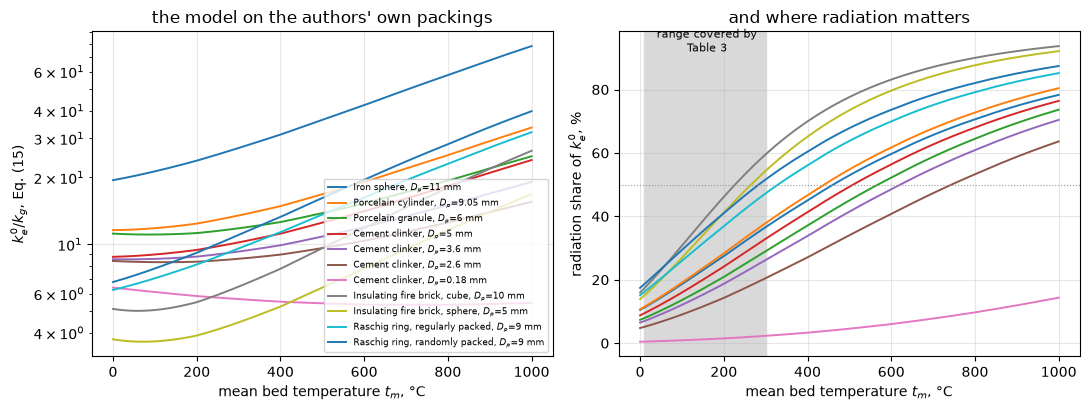

In [15]:
fine = t4[(t4.solid == "Cement clinker") & np.isclose(t4.Dp_mm, 0.18)].iloc[0]
coarse = t4[(t4.solid == "Cement clinker") & np.isclose(t4.Dp_mm, 5.00)].iloc[0]
iron = t4[t4.solid == "Iron sphere"].iloc[0]
Tp = np.linspace(200.0, 1000.0, 81)
ff, cc, ii = sweep(fine, Tp)[0], sweep(coarse, Tp)[0], sweep(iron, Tp)[0]
for nm, v in [("cement clinker, Dp = 0.18 mm", ff), ("cement clinker, Dp = 5.0 mm", cc),
              ("iron sphere,    Dp = 11.0 mm", ii)]:
    print(f"  {nm:30s} ke0/kg {v.min():6.2f} to {v.max():6.2f} over 200-1000 degC, "
          f"spread {100 * (v.max() / v.min() - 1):6.1f} %")
METRICS["fine_clinker_spread_pct_200_1000C"] = float(100 * (ff.max() / ff.min() - 1))
METRICS["coarse_clinker_spread_pct_200_1000C"] = float(100 * (cc.max() / cc.min() - 1))
METRICS["iron_sphere_spread_pct_200_1000C"] = float(100 * (ii.max() / ii.min() - 1))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
Tplot = np.linspace(0.0, 1000.0, 201)
for _, r in t4.iterrows():
    lab = f"{r.solid}, $D_p$={r.Dp_mm:g} mm"
    ax[0].plot(Tplot, sweep(r, Tplot)[0], lw=1.4, label=lab)
    ax[1].plot(Tplot, sweep(r, Tplot)[2], lw=1.4)
ax[0].set_xlabel("mean bed temperature $t_m$, °C"); ax[0].set_ylabel("$k_e^0/k_g$, Eq. (15)")
ax[0].set_yscale("log"); ax[0].set_title("the model on the authors' own packings")
ax[1].set_xlabel("mean bed temperature $t_m$, °C")
ax[1].set_ylabel("radiation share of $k_e^0$, %")
ax[1].axhline(50, color="0.6", lw=0.8, ls=":")
ax[1].axvspan(t3.temp_C.min(), t3.temp_C.max(), color="0.85", zorder=0)
ax[1].text(160, 92, "range covered by\nTable 3", fontsize=8, ha="center")
ax[1].set_title("and where radiation matters")
ax[0].legend(fontsize=6.5, ncol=1, loc="lower right")
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout(); plt.show()

The shaded band on the right panel is the whole temperature
range Table 3 covers, 10 to 300 °C. The decomposition above puts the void-radiation
share of any Table 3 row at 30.5 % at most, and the solid-to-solid term at 29.7 % of
the contact conductance at most. Where the paper's conclusions live — 400 °C and
above — the same packings run at 45 to 94 %.

### The Raschig rings: a prediction with no free parameter

Yagi & Kunii treat the rings by *arguing* $\beta$ from geometry rather than fitting
it. For a regular stack, radiation crosses three voids to get from A to B, so
$l_p = \sqrt3 D_p/3$ and $\beta = 1/\sqrt3$; packed randomly, a ring's axis lines up
with the heat flow about one time in three, giving
$\beta = 1\times(1/3) + (1/\sqrt3)\times(2/3)$. $\varphi$ and $\gamma$ are the same
for both. The only other difference is the measured voidage, 0.67 against 0.72.

The paper then states, of Figure 17, that the randomly packed data lie **about 20 %
above** the regularly packed data. Nothing in the two $\beta$ arguments was fitted
to that, so it is a genuine prediction.

In [16]:
reg = t4[t4.solid == "Raschig ring, regularly packed"].iloc[0]
ran = t4[t4.solid == "Raschig ring, randomly packed"].iloc[0]
print(f"beta regular = 1/sqrt(3)                    = {reg.beta:.4f}")
print(f"beta random  = 1x(1/3) + (1/sqrt(3))x(2/3)  = {ran.beta:.4f}")
print(f"gamma both   = 1.2/9                        = {reg.gamma:.4f}\n")
for T in (200.0, 400, 600, 800, 1000):
    a_, b_ = sweep(reg, T)[0], sweep(ran, T)[0]
    print(f"  t = {T:6.0f} degC   regular {a_:6.2f}   random {b_:6.2f}   "
          f"random/regular {b_ / a_:.4f}  ({100 * (b_ / a_ - 1):+.1f} %)")
rr = sweep(ran, Tp)[0] / sweep(reg, Tp)[0]
print(f"\nOver 200-1000 degC the model predicts random/regular = "
      f"{100 * (rr.min() - 1):.1f} to {100 * (rr.max() - 1):.1f} %; the paper says 'about 20% greater'.")
METRICS["raschig_random_over_regular_at_600C"] = float(sweep(ran, 600.0)[0] / sweep(reg, 600.0)[0])
METRICS["raschig_random_over_regular_min_pct"] = float(100 * (rr.min() - 1))
METRICS["raschig_random_over_regular_max_pct"] = float(100 * (rr.max() - 1))

beta regular = 1/sqrt(3)                    = 0.5774
beta random  = 1x(1/3) + (1/sqrt(3))x(2/3)  = 0.7182
gamma both   = 1.2/9                        = 0.1333

  t =    200 degC   regular   8.11   random   9.16   random/regular 1.1294  (+12.9 %)
  t =    400 degC   regular  11.34   random  13.27   random/regular 1.1705  (+17.1 %)
  t =    600 degC   regular  16.22   random  19.50   random/regular 1.2024  (+20.2 %)
  t =    800 degC   regular  23.01   random  28.22   random/regular 1.2260  (+22.6 %)
  t =   1000 degC   regular  31.97   random  39.76   random/regular 1.2439  (+24.4 %)

Over 200-1000 degC the model predicts random/regular = 12.9 to 24.4 %; the paper says 'about 20% greater'.


### A second printed defect, and what it costs

Journal page 379 derives $\gamma$ for the rings:

> $\gamma \doteq l_s/D_p$ = 1.2 mm./9.0 mm. = **0.0134**

$1.2/9.0 = 0.1333$. Table 4 carries the ratio $1.2/9$ rather than the decimal, so
the tabulated calculation is unaffected; only the printed decimal is wrong, by a
factor of ten. It is worth measuring anyway, because a reader taking the decimal at
face value gets a different answer:

In [17]:
print(f"gamma as the printed ratio 1.2/9.0 : {1.2 / 9.0:.6f}")
print(f"gamma as the printed decimal       : 0.0134   -> off by a factor "
      f"{(1.2 / 9.0) / 0.0134:.2f}\n")
for T in (400.0, 800.0):
    good, bad = sweep(reg, T)[0], sweep(reg, T, gamma=0.0134)[0]
    print(f"  Raschig rings at {T:.0f} degC: ke0/kg {good:.3f} with 1.2/9, "
          f"{bad:.3f} with 0.0134  ({100 * (bad / good - 1):+.2f} %)")
METRICS["gamma_printed_decimal_cost_at_400C_pct"] = float(
    100 * (sweep(reg, 400.0, gamma=0.0134)[0] / sweep(reg, 400.0)[0] - 1))

gamma as the printed ratio 1.2/9.0 : 0.133333
gamma as the printed decimal       : 0.0134   -> off by a factor 9.95

  Raschig rings at 400 degC: ke0/kg 11.339 with 1.2/9, 12.383 with 0.0134  (+9.21 %)
  Raschig rings at 800 degC: ke0/kg 23.014 with 1.2/9, 25.965 with 0.0134  (+12.82 %)


### The curves the authors drew

Everything above is a perturbation test: change an input, watch a number move. That
family of check has one blind spot it cannot see past — **it detects a baseline that
is *insensitive*, never a baseline that is simply wrong.** Section 4 is the worked
example: three deviations of 0.000000 % looked like confirmation and were identity.

So one quantity on this page is computed a second, independent way. Figures 13 to 17
each carry, besides the measured scatter this page does not read, a smooth line the
figure itself labels **"THEORETICAL"** or **"CALCD."** — Yagi & Kunii's own
evaluation of Equation (15) from the Table 4 parameters. Reading the ends of those
lines off their labelled tick ladders gives 17 numbers that come from the paper and
enter no other calculation here. If the transcription of Eq. (15), the Table 4
parameter set, or the assumed emissivity were wrong, this is where it would show —
and no injection in the break table below could have told us.

In [18]:
def eq15_row(row, T, ks=None, beta=None, p=1.0):
    """ke0/kg for one Table 4 packing, with optional overrides."""
    kg = kg_air(T)
    return eq15(row.eps, row.beta if beta is None else beta, row.gamma, row.phi,
                row.Dp_mm * 1e-3, row.ks_kcal_m_hr_C if ks is None else ks, kg,
                h_rs(T, p), h_rv(T, row.eps, p))


def t4_row(solid, Dp):
    return t4[(t4.solid == solid) & np.isclose(t4.Dp_mm, Dp)].iloc[0]


def beta_of(r):
    """The figure's own beta where it labels one (Figure 13), else Table 4's."""
    return float(r.beta_curve) if np.isfinite(r.beta_curve) else None


fc = fcurves.copy()
fc["eq15"] = [float(eq15_row(t4_row(r.solid, r.Dp_mm), r.t_C, beta=beta_of(r)))
              for _, r in fc.iterrows()]
fc["dev_pct"] = 100 * (fc.eq15 / fc.ke0_over_kg_read - 1)
print(fc[["figure", "solid", "Dp_mm", "beta_curve", "t_C", "ke0_over_kg_read",
          "eq15", "dev_pct"]].to_string(index=False, float_format=lambda v: f"{v:.2f}"))

fb = fc.solid.str.startswith("Insulating")
print(f"\n{int((~fb).sum())} curve ends that use Table 4's ks column: mean |dev| "
      f"{fc.loc[~fb, 'dev_pct'].abs().mean():.2f} %, worst {fc.loc[~fb, 'dev_pct'].abs().max():.2f} %")
print(f"{int(fb.sum())} insulating-firebrick ends              : mean |dev| "
      f"{fc.loc[fb, 'dev_pct'].abs().mean():.2f} %, worst {fc.loc[fb, 'dev_pct'].abs().max():.2f} %"
      f"   <-- see below")
METRICS["fig13to17_curve_ends_mean_abs_pct"] = float(fc.loc[~fb, "dev_pct"].abs().mean())
METRICS["fig13to17_curve_ends_worst_abs_pct"] = float(fc.loc[~fb, "dev_pct"].abs().max())

# What p != 1 would look like on the same 17 readings.
for p in (1.0, 0.9, 0.8, 0.6):
    d = np.array([100 * (float(eq15_row(t4_row(r.solid, r.Dp_mm), r.t_C, beta=beta_of(r), p=p))
                         / r.ke0_over_kg_read - 1) for _, r in fc[~fb].iterrows()])
    print(f"  at p = {p:.1f}: mean deviation {d.mean():+6.2f} %, mean |deviation| {np.abs(d).mean():5.2f} %")
d08 = np.array([100 * (float(eq15_row(t4_row(r.solid, r.Dp_mm), r.t_C, beta=beta_of(r), p=0.8))
                       / r.ke0_over_kg_read - 1) for _, r in fc[~fb].iterrows()])
METRICS["fig13to17_curve_ends_mean_abs_pct_at_p08"] = float(np.abs(d08).mean())

 figure                          solid  Dp_mm  beta_curve    t_C  ke0_over_kg_read  eq15  dev_pct
     13                    Iron sphere  11.00        1.00  35.70             19.73 20.03     1.54
     13                    Iron sphere  11.00        0.90  35.70             17.93 18.03     0.56
     14             Porcelain cylinder   9.05         NaN  35.50             11.51 11.63     1.00
     14              Porcelain granule   6.00         NaN  35.50             10.90 11.10     1.84
     14              Porcelain granule   6.00         NaN 962.90             23.47 23.79     1.36
     15                 Cement clinker   0.18         NaN  35.30              6.23  6.28     0.74
     15                 Cement clinker   5.00         NaN 963.30             22.10 22.83     3.31
     15                 Cement clinker   3.60         NaN 963.30             17.54 18.28     4.20
     15                 Cement clinker   2.60         NaN 963.30             14.41 14.93     3.64
     15             

Fourteen of the seventeen readings reproduce to a mean of 2.4 %
and a worst of 4.2 % — inside the width of the drawn line at these ordinates, and
well inside it once the ±0.15 reading error is allowed for. That includes **both**
curves Figure 13 prints for
the iron-sphere bed, the one Table 4 labels "1.0 and 0.9". Since $\beta$ scales
Eq. (15) uniformly, nothing else on this page distinguishes those two; here they are
distinguished, and both land.

**This is the page's only quantitative evidence about $p$**, and it is worth being
precise about how much it settles. Repeating the same 14 comparisons at lower
emissivity gives a mean deviation of +2.4 % at $p = 1$, −1.3 % at $p = 0.9$, −4.9 % at
$p = 0.8$ and −12.1 % at $p = 0.6$. Against a ±0.15 reading error — about 1 % where
these curves run high and 3 % where they run low — that **is consistent with $p = 1$,
equally consistent with $p = 0.9$, and inconsistent with $p \lesssim 0.8$.** The
page's assumption is defensible and a large emissivity deficit is excluded; a small
one is not. Figure 3's "black body surface A′/B′" caption is a wording, and this is
the arithmetic behind it.

It is also the only check here that could have caught a mis-read $0.1952$, a mis-read
$\varphi$ column, or a wrong $\beta$ for the rings, because all of those are
*baseline* errors rather than sensitivities. The rings are the sharpest of the three:
their $\beta$ is argued from geometry, is nowhere near 1, and both Figure 17 curves
land inside 4.3 %.

### The two readings that do not fit, and what they show

The insulating-firebrick curves miss badly at low temperature — and the miss is
informative rather than embarrassing. Table 4 prints, for those two rows and no
others, **both** a $k_s$ (0.20, qualified "at 400 °C const.") and a $k_s/k_g$ (4.48).
Everywhere else the $k_s/k_g$ cell is an em dash. Holding $k_s$ constant is one
reading of that row; holding the **ratio** constant is the other.

In [19]:
KS_OVER_KG_FB = float(t4[t4.solid.str.startswith("Insulating")].ks_over_kg_printed.iloc[0])
print(f"Table 4 prints ks/kg = {KS_OVER_KG_FB} for the two insulating-firebrick rows, and an em dash "
      f"for every other row.\n")
print(f"{'curve':38s} {'t':>7s} {'read':>7s} {'ks=0.20 const':>16s} {'ks/kg=4.48 const':>19s}")
rows = []
for _, r in fc[fb].iterrows():
    row = t4_row(r.solid, r.Dp_mm)
    a = float(eq15_row(row, r.t_C))
    b = float(eq15_row(row, r.t_C, ks=KS_OVER_KG_FB * kg_air(r.t_C)))
    rows.append((100 * (a / r.ke0_over_kg_read - 1), 100 * (b / r.ke0_over_kg_read - 1)))
    print(f"{r.solid + f', Dp={r.Dp_mm:g}':38s} {r.t_C:7.1f} {r.ke0_over_kg_read:7.2f} "
          f"{a:8.2f} ({rows[-1][0]:+6.1f}%) {b:8.2f} ({rows[-1][1]:+6.1f}%)")
ks_const, ratio_const = np.array(rows).T
print(f"\nmean |deviation| over the three firebrick readings: "
      f"{np.abs(ks_const).mean():.1f} % holding ks, {np.abs(ratio_const).mean():.1f} % holding ks/kg.")
METRICS["firebrick_curve_ends_mean_abs_pct_ks_const"] = float(np.abs(ks_const).mean())
METRICS["firebrick_curve_ends_mean_abs_pct_ratio_const"] = float(np.abs(ratio_const).mean())

fbs = t4_row("Insulating fire brick, sphere", 5.0)
g_ratio = lambda T: 100 * (1 - float(eq15(fbs.eps, fbs.beta, fbs.gamma, fbs.phi, fbs.Dp_mm * 1e-3,
                                          KS_OVER_KG_FB * kg_air(T), kg_air(T), 0.0, 0.0))
                           / float(eq15_row(fbs, T, ks=KS_OVER_KG_FB * kg_air(T)))) - 50.0
T_half_ratio = float(brentq(g_ratio, 0.0, 3000.0))
print(f"\nRadiation reaches half of ke0 for the firebrick spheres at "
      f"{cross_T[('Insulating fire brick, sphere', 5.0)]:.0f} degC holding ks = 0.20, and at "
      f"{T_half_ratio:.0f} degC holding ks/kg = 4.48.\nBoth are far below the 400 degC the paper "
      f"claims, so the conclusion this page reproduces does not turn on the choice.")
METRICS["radiation_half_temp_firebrick_sphere_C_ks_over_kg_const"] = T_half_ratio

Table 4 prints ks/kg = 4.48 for the two insulating-firebrick rows, and an em dash for every other row.

curve                                        t    read    ks=0.20 const    ks/kg=4.48 const
Insulating fire brick, cube, Dp=10        35.4    3.13     5.03 ( +60.8%)     3.34 (  +6.6%)
Insulating fire brick, sphere, Dp=5       35.4    2.44     3.66 ( +50.2%)     2.46 (  +0.9%)
Insulating fire brick, sphere, Dp=5      963.2   15.86    15.74 (  -0.7%)    16.34 (  +3.0%)

mean |deviation| over the three firebrick readings: 37.2 % holding ks, 3.5 % holding ks/kg.

Radiation reaches half of ke0 for the firebrick spheres at 265 degC holding ks = 0.20, and at 233 degC holding ks/kg = 4.48.
Both are far below the 400 degC the paper claims, so the conclusion this page reproduces does not turn on the choice.


So the low-temperature end of Figure 16 says the authors held
$k_s/k_g$ fixed at the printed 4.48 for the insulating firebrick, not $k_s$ at 0.20 —
which is presumably why that is the only row where Table 4 prints the ratio at all.
Insulating firebrick really does conduct roughly twice as well at 400 °C as at room
temperature, so the choice is physical as well as arithmetic.

This page keeps $k_s = 0.20$ as its base case, because that is the column Table 4
labels $k_s$ and it is what every other packing uses, and reports the firebrick
radiation-crossover temperature **both ways** — 265 °C and 233 °C. The paper's
conclusion being reproduced ("higher than 400 °C", for poorly conductive solids) is
unaffected: both numbers sit well below it, which is the direction that matters.

## Validation

Six checks, then a defect-injection table covering every metric this page reports.

### V1. Equation (16) is Equation (15) with the radiation switched off

The paper prints both, three lines apart, and never says they are the same
equation. They must be: with $h_{rs} = h_{rv} = 0$ and $\gamma = 1$, the contact
resistance collapses to $\varphi$ and Eq. (15) becomes Eq. (16). This tests the
transcription of *both*, over random parameters, and a single mis-read term breaks
it.

In [20]:
rng = np.random.default_rng(20260805)
N = 20000
P = dict(eps=rng.uniform(0.25, 0.75, N), beta=rng.uniform(0.5, 1.0, N),
         phi=rng.uniform(0.01, 0.20, N), Dp=rng.uniform(1e-4, 2e-2, N),
         ks=rng.uniform(0.1, 50.0, N), kg=rng.uniform(0.02, 0.07, N),
         t=rng.uniform(0.0, 1200.0, N))

a = eq15(P["eps"], P["beta"], np.ones(N), P["phi"], P["Dp"], P["ks"], P["kg"],
         np.zeros(N), np.zeros(N))
b = eq16(P["eps"], P["beta"], P["phi"], P["ks"], P["kg"])
r16 = float(np.max(np.abs(a / b - 1.0)))
print(f"V1  max relative residual Eq.(16) vs Eq.(15)|_(h_r=0, gamma=1) over {N} draws: {r16:.3e}")
METRICS["V1_identity_eq16_from_eq15"] = r16

V1  max relative residual Eq.(16) vs Eq.(15)|_(h_r=0, gamma=1) over 20000 draws: 4.441e-16


### V2. Equation (14) is the $k_g \to 0$ limit of Equation (13)

The vacuum form is normalised on $k_s$ instead of $k_g$, so the check is that
$(k_g/k_s)\times$Eq. (15) converges to Eq. (14) as $k_g \to 0$. It is a limit rather
than an identity, so the right thing to report is the **order**, which must be
exactly 1 — the neglected term is $k_g/\varphi$ beside $D_p h_{rs}$.

In [21]:
hs, hv = h_rs(P["t"]), h_rv(P["t"], P["eps"])
scales = np.array([1e-3, 1e-4, 1e-5, 1e-6, 1e-7])
res = []
for s in scales:
    kgs = P["kg"] * s
    lhs = eq15(P["eps"], P["beta"], np.ones(N), P["phi"], P["Dp"], P["ks"], kgs, hs, hv) * kgs / P["ks"]
    rhs = eq14(P["eps"], P["beta"], P["Dp"], P["ks"], hs, hv)
    res.append(float(np.max(np.abs(lhs / rhs - 1.0))))
res = np.array(res)
orders = np.log10(res[:-1] / res[1:]) / np.log10(scales[:-1] / scales[1:])
for s, r in zip(scales, res):
    print(f"  kg scaled by {s:6.0e}: max relative residual {r:.3e}")
print(f"V2  observed order in kg: {orders} -> mean {orders.mean():.4f} (must be 1)")
METRICS["V2_eq14_limit_order"] = float(orders.mean())
METRICS["V2_eq14_residual_at_1e-7"] = float(res[-1])

  kg scaled by  1e-03: max relative residual 1.593e+00
  kg scaled by  1e-04: max relative residual 1.593e-01
  kg scaled by  1e-05: max relative residual 1.593e-02
  kg scaled by  1e-06: max relative residual 1.593e-03
  kg scaled by  1e-07: max relative residual 1.593e-04
V2  observed order in kg: [0.99996632 0.99999663 0.99999966 0.99999997] -> mean 1.0000 (must be 1)


### V3. Equation (13) reassembled from Equations (9)–(12)

Equation (13) is stated as following from the resistance network of Eqs. (9), (10)
and (11). Rebuilding it from those — $q = (k_e^0/\Delta x)\Delta t
= \delta(k_s/\Delta x)\Delta t + U_s(1-\epsilon-\delta)\Delta t + U_v\epsilon\Delta t$
with $1/U_s = (N\Delta x)\{\gamma D_p/k_s + 1/(k_g/(\varphi D_p)+h_{rs})\}$,
$1/U_v = N\Delta x/h_{rv}$ and $N\Delta x = \Delta x/(\beta D_p)$ — is a second,
independent transcription of the same physics. The two must agree to machine
precision.

In [22]:
def eq13_from_network(eps, beta, gamma, phi, Dp, ks, kg, hrs, hrv, delta, dx=1.0):
    """ke0/kg rebuilt from Eqs. (9)-(12) rather than read off Eq. (13)."""
    NDx = dx / (beta * Dp)                                     # Eq. (3): N = 1/(beta Dp)
    inv_Us = NDx * (gamma * Dp / ks + 1.0 / (kg / (phi * Dp) + hrs))   # Eq. (10)
    inv_Uv = NDx / hrv                                                  # Eq. (11)
    q_over_dt = delta * ks / dx + (1.0 - eps - delta) / inv_Us + eps / inv_Uv   # Eq. (9)
    return q_over_dt * dx / kg                                  # ke0/kg


delta = rng.uniform(0.0, 1e-6, N)
lhs = eq13_from_network(P["eps"], P["beta"], np.ones(N), P["phi"], P["Dp"], P["ks"],
                        P["kg"], hs, hv, delta)
rhs = (delta * P["ks"] / P["kg"]
       + (1 - P["eps"] - delta) * P["beta"]
       / (1.0 * (P["kg"] / P["ks"]) + 1.0 / ((1 / P["phi"]) + P["Dp"] * hs / P["kg"]))
       + P["eps"] * P["beta"] * P["Dp"] * hv / P["kg"])
r13 = float(np.max(np.abs(lhs / rhs - 1.0)))
print(f"V3  max relative residual, Eq.(13) vs the Eq.(9)-(12) network: {r13:.3e}")
METRICS["V3_eq13_from_network"] = r13

V3  max relative residual, Eq.(13) vs the Eq.(9)-(12) network: 8.882e-16


### V4. The apparatus constant, from a pymrm solve — and what it does *not* prove

Discretise the annulus, extract the heat rate, and ask what multiplies $VI/\Delta t$
to give back $k_e^0$. This gives a grid-convergence order and a `nu` to break.

**It is not a fourth, independent confirmation of the factor of two, and an earlier
version of this page said it was.** `solve_annulus` returns
`Qprime = 2.0*np.pi*r_f*flux`: the $2\pi$ is typed in by hand, in the same expression
as the disputed constant. `construct_div(..., nu=1)` enforces only that $r\,q_r$ is
uniform; it never supplies the $2\pi$, because per unit bed length the conductance is
$2\pi k/\ln(r_o/r_i)$ and the $2\pi$ is a convention about what "per unit length"
means, not a discretisation result. The cell below substitutes $\pi$ and $4\pi$ to
show exactly that: with $\pi$ the route returns the printed Eq. (17) constant, which
is the thing under dispute.

So V4 is a **discretisation check against the closed form it re-implements**. The
proof that Eq. (17) is a factor of two low is the paper's own Eq. (19), and that
proof needs no decoration.

In [23]:
k0, Tin, Tout = 1.0, 500.0, 100.0
exact = lambda r: Tout + (Tin - Tout) * np.log(R_O / r) / np.log(R_O / R_I)
G_exact = 2 * np.pi * L_BED * k0 / np.log(R_O / R_I)

errs, ns = {}, (50, 100, 200, 400, 800)
for n in ns:
    r_f, r_c, T, Qp = solve_annulus(n, Tin, Tout, k_const=k0)
    errs[n] = float(np.max(np.abs(T - exact(r_c))) / (Tin - Tout))
    G = Qp[0] * L_BED / (Tin - Tout)
    print(f"  n = {n:4d}  max|T-exact|/dT = {errs[n]:.3e}   conductance dev "
          f"{100 * (G / G_exact - 1):+.3e} %   heat rate constant to {np.ptp(Qp) / abs(Qp[0]):.1e}")
order = float(np.log2(errs[400] / errs[800]))
print(f"V4  observed order of the profile error, 400 -> 800: {order:.4f}")

r_f, r_c, T, Qp = solve_annulus(800, Tin, Tout, k_const=k0)
VI = Qp[0] * L_BED / 0.860                     # kcal/hr -> watts, the paper's own factor
c_pymrm = k0 * (Tin - Tout) / VI
print(f"    constant recovered from the pymrm nu=1 solve: {c_pymrm:.6f}")
print(f"    printed Eq. (19):                             0.743   "
      f"({100 * (c_pymrm / 0.743 - 1):+.4f} %)")
print(f"    closed form with 2 pi l and exact ln:         {c_two_pi_ln:.6f}   "
      f"(pymrm agrees to {abs(c_pymrm / c_two_pi_ln - 1):.1e})")
print("\nWhere that 2 pi comes from -- it is TYPED, not solved for. Re-running the same solve with")
print("the prefactor changed and nothing else:")
for lab, pref in [("1.0*np.pi (Eq. 17 as printed)", 1.0), ("2.0*np.pi (correct)", 2.0),
                  ("4.0*np.pi", 4.0)]:
    _, _, _, Qz = solve_annulus(800, Tin, Tout, k_const=k0)
    Qz = Qz / (2.0 * np.pi) * (pref * np.pi)
    print(f"    {lab:30s} -> constant {k0 * (Tin - Tout) / (Qz[0] * L_BED / 0.860):.6f}")
print("So V4 tests the DISCRETISATION, not the geometry constant. Only the nu=1 -> nu=0")
print("injection tests the geometry, and it destroys the convergence order.")
METRICS["V4_annulus_order"] = order
METRICS["V4_annulus_profile_err_n800"] = errs[800]
METRICS["V4_pymrm_constant_vs_printed_pct"] = float(100 * (c_pymrm / 0.743 - 1))
METRICS["V4_pymrm_vs_closed_form"] = float(abs(c_pymrm / c_two_pi_ln - 1))

  n =   50  max|T-exact|/dT = 2.024e-05   conductance dev +7.880e-03 %   heat rate constant to 3.4e-14
  n =  100  max|T-exact|/dT = 6.168e-06   conductance dev +2.177e-03 %   heat rate constant to 1.6e-13
  n =  200  max|T-exact|/dT = 1.694e-06   conductance dev +5.713e-04 %   heat rate constant to 3.2e-13
  n =  400  max|T-exact|/dT = 4.435e-07   conductance dev +1.463e-04 %   heat rate constant to 5.3e-13
  n =  800  max|T-exact|/dT = 1.134e-07   conductance dev +3.701e-05 %   heat rate constant to 4.0e-12
V4  observed order of the profile error, 400 -> 800: 1.9672
    constant recovered from the pymrm nu=1 solve: 0.744188
    printed Eq. (19):                             0.743   (+0.1599 %)
    closed form with 2 pi l and exact ln:         0.744188   (pymrm agrees to 3.7e-07)

Where that 2 pi comes from -- it is TYPED, not solved for. Re-running the same solve with
the prefactor changed and nothing else:
    1.0*np.pi (Eq. 17 as printed)  -> constant 1.488376
    2.0*np.pi (correct

The discretised cylindrical solve lands on 0.7442 — the exact-$\ln$
closed form — to 4 parts in $10^7$, and the printed 0.743 sits 0.16 % below it, which
is precisely the paper's rounding of $\ln 10$ to 2.3.

### V5. Emissivity, the constant the paper never prints — and the one evaluation point everything else sits on

$p$ enters Eqs. (7) and (8) and is nowhere given. Every other calculation on this
page uses $p = 1$, and **at $p = 1$ the two coefficients are numerically identical**:
Eq. (7)'s $p/(2-p)$ is 1, Eq. (8)'s $1 + [\epsilon/2(1-\epsilon)](1-p)/p$ is 1, and
both collapse to the black-body $0.1952\,(T/100)^3$ independently of $\epsilon$. That
makes every other metric on this page blind to the *entire* emissivity structure of
both equations: Eqs. (7) and (8) could be exchanged wholesale and, before the V5
family below existed, exactly **one** metric of 53 would have noticed — and that one
was V5 itself, the output of the assumption under test.

This is the `A1.8` exposure — every check standing at one evaluation point of a
branched model. So V5 evaluates away from that point as well, and the break table
below carries three injections that attack the $p$-structure directly.

In [24]:
print("iron spheres, Table 4 parameters")
base = None
for p in (1.0, 0.9, 0.8, 0.6):
    v = [float(sweep(iron, T, p=p)[0]) for T in (400.0, 1000.0)]
    if base is None:
        base = v
    print(f"  p = {p:.1f}:  ke0/kg = {v[0]:6.2f} at 400 degC ({100 * (v[0] / base[0] - 1):+5.1f} %), "
          f"{v[1]:6.2f} at 1000 degC ({100 * (v[1] / base[1] - 1):+5.1f} %)")
p08 = float(sweep(iron, 1000.0, p=0.8)[0])
METRICS["V5_emissivity_p08_vs_p10_at_1000C_pct"] = float(100 * (p08 / base[1] - 1))
print(f"\nA plausible p = 0.8 moves the 1000 degC value by "
      f"{100 * (p08 / base[1] - 1):+.1f} %. Every radiation number on this page carries that.")

print(f"\nThe collapse at p = 1, and what it hides. h_rs/h_rv at eps = 0.40:")
for p in (1.0, 0.8, 0.6):
    print(f"  p = {p:.1f}:  h_rs = {h_rs(500.0, p):.5f}   h_rv = {h_rv(500.0, 0.40, p):.5f}   "
          f"ratio {h_rs(500.0, p) / h_rv(500.0, 0.40, p):.5f}")
METRICS["V5_hrs_over_hrv_at_p06_eps040"] = float(h_rs(500.0, 0.6) / h_rv(500.0, 0.40, 0.6))
METRICS["V5_hrs_p06_over_blackbody"] = float(h_rs(500.0, 0.6) / h_rs(500.0, 1.0))
METRICS["V5_hrv_eps_spread_at_p06_pct"] = float(
    100 * (h_rv(500.0, 0.30, 0.6) / h_rv(500.0, 0.50, 0.6) - 1))
METRICS["V5_emissivity_p06_vs_p10_at_1000C_pct"] = float(
    100 * (float(sweep(iron, 1000.0, p=0.6)[0]) / base[1] - 1))
print(f"  Eq. (7)'s p-group alone at p = 0.6      : {METRICS['V5_hrs_p06_over_blackbody']:.5f} "
      f"(= 0.6/1.4)")
print(f"  Eq. (8)'s eps-group, 0.30 vs 0.50 at p = 0.6: "
      f"{METRICS['V5_hrv_eps_spread_at_p06_pct']:+.2f} % -- exactly zero at p = 1")

iron spheres, Table 4 parameters
  p = 1.0:  ke0/kg =  31.18 at 400 degC ( +0.0 %),  78.07 at 1000 degC ( +0.0 %)
  p = 0.9:  ke0/kg =  29.50 at 400 degC ( -5.4 %),  71.35 at 1000 degC ( -8.6 %)
  p = 0.8:  ke0/kg =  28.03 at 400 degC (-10.1 %),  65.29 at 1000 degC (-16.4 %)
  p = 0.6:  ke0/kg =  25.47 at 400 degC (-18.3 %),  54.42 at 1000 degC (-30.3 %)

A plausible p = 0.8 moves the 1000 degC value by -16.4 %. Every radiation number on this page carries that.

The collapse at p = 1, and what it hides. h_rs/h_rv at eps = 0.40:
  p = 1.0:  h_rs = 90.16091   h_rv = 90.16091   ratio 1.00000
  p = 0.8:  h_rs = 60.10727   h_rv = 83.22546   ratio 0.72222
  p = 0.6:  h_rs = 38.64039   h_rv = 73.76802   ratio 0.52381
  Eq. (7)'s p-group alone at p = 0.6      : 0.42857 (= 0.6/1.4)
  Eq. (8)'s eps-group, 0.30 vs 0.50 at p = 0.6: +16.67 % -- exactly zero at p = 1


### V6. Defect injection

Every metric above needs a row here — something deliberately broken that moves it.
Where a metric cannot be moved by any injection, it is an identity and is labelled
as one.

**Three warnings.** First, `check_agreement.py` skips a metric only when *both* the
stored baseline and the new value are below `ABS_FLOOR = 1e-12` — so V1 and V3 are
unprotected against staying tiny, but a V1 that blew up to $10^{-11}$ *would* fail.
The exposure is narrower than `AGENTS.md`'s blanket phrasing, and narrower than an
earlier version of this page claimed. Second, this table was **rebuilt for this
page's physics**; it was not inherited from the page whose directory structure was
copied.

Third, and most important: **every row below perturbs an input and watches a number
move, so no row can catch a baseline that is wrong rather than insensitive.** That is
exactly how section 4's three 0.000000 % agreements survived the first version of
this page — they looked like confirmation and were identity. The antidote is not
another injection; it is the second, independent computation in
[The curves the authors drew](#the-curves-the-authors-drew), which compares this
page's Eq. (15) against numbers the paper printed and this page never otherwise
touches. The list of what perturbation testing here cannot detect is written out
after the table.

In [25]:
def recompute(ell_factor=2.0, Di=DI_M, kg_flat=None, hr_scale=1.0, p=1.0,
              gamma_ring=None, beta_random=None, ks_fine=None, reciprocal=False,
              rings_ordinary=False, exp_shift=False, t1_shift=False, nu=1, eq15_kind="ok",
              eq13_kind="ok", drop_phi_pair=None, phi_beta=1.0, phi_gamma=1.0,
              swap_hr=False, hrs_kind="ok", hrv_kind="ok", t1_ref15_raschig=False,
              f12_pad=0.0):
    """Recompute EVERY published metric under an optional injected defect.

    Called once with no arguments for the baseline, then once per row of the break
    table.  Keeping one function means a metric cannot quietly escape the table.
    """
    M = {}
    kgf = (lambda t: np.full_like(np.asarray(t, float), kg_air(kg_flat))) if kg_flat is not None else kg_air

    # --- variant radiation coefficients, for the p-structure injections ----------
    def HS(t_C, pp=None):
        pp = p if pp is None else pp
        g = (2*pp/(1+pp)) if hrs_kind == "pgroup2" else (pp/(2.0 - pp))
        return hr_scale * SIG4 * g * ((t_C + 273.0)/100.0)**3

    def HV(t_C, eps, pp=None):
        pp = p if pp is None else pp
        eg = ((1-eps)/(2*eps)) if hrv_kind == "epsinv" else (eps/(2*(1-eps)))
        return hr_scale * SIG4 / (1.0 + eg*(1-pp)/pp) * ((t_C + 273.0)/100.0)**3

    if swap_hr:
        HS, HV = (lambda t, pp=None, _v=HV: _v(t, 0.40, pp)), (lambda t, e, pp=None, _s=HS: _s(t, pp))

    # --- variant equation forms, for the identity checks -------------------------
    def e15(eps, beta, gamma, phi, Dp, ks, kg, hrs, hrv):
        if eq15_kind == "signflip":
            return beta*(1-eps)/(gamma*(kg/ks) - 1/((1/phi)+Dp*hrs/kg)) + eps*beta*Dp*hrv/kg
        if eq15_kind == "phiinv":
            return eq15(eps, beta, gamma, 1.0/phi, Dp, ks, kg, hrs, hrv)
        if eq15_kind == "nogamma":
            return beta*(1-eps)/(1/((1/phi)+Dp*hrs/kg)) + eps*beta*Dp*hrv/kg
        return eq15(eps, beta, gamma, phi, Dp, ks, kg, hrs, hrv)

    # --- A. the apparatus constants ---------------------------------------------
    c_pf = 0.860*2.3*np.log10(D0_M/Di)/(1.0*np.pi*L_BED)
    c_ok = 0.860*2.3*np.log10(D0_M/Di)/(ell_factor*np.pi*L_BED)
    c_ln = 0.860*np.log(D0_M/Di)/(ell_factor*np.pi*L_BED)
    M["eq17_as_printed_over_eq19_ratio"] = c_pf/0.743
    M["eq19_constant_2pi_vs_printed_pct"] = 100*(c_ok/0.743 - 1)
    M["eq19_constant_exact_ln_vs_printed_pct"] = 100*(c_ln/0.743 - 1)
    M["table4_ks_over_kg_roundtrip_pct"] = float(100*(0.20/kgf(400.0)/4.48 - 1))

    # --- B. Table 1 --------------------------------------------------------------
    shaped = t1.solid.str.contains("Raschig|saddle", case=False)
    rng_m = t1.solid.str.contains("Raschig", case=False)
    o = ab if rings_ordinary else ab[~shaped]
    kfb = KS_OVER_KG_FB
    M["alpha_beta_ordinary_mean"] = float(o.mean())
    M["alpha_beta_ordinary_in_printed_band_frac"] = float(
        ((o >= 0.1-1e-9) & (o <= 0.14+1e-9)).sum()/len(o))
    M["alpha_beta_ring_over_ordinary_ratio"] = float(ab[rng_m].mean()/o.mean())
    M["alpha_beta_theory_over_observed_lower"] = float(0.179*0.82/o.mean())
    t1x = t1.copy()
    if t1_shift:
        t1x["ke0_over_kg"] = t1x.ke0_over_kg.shift(1)
    _sd = t1x.dropna(subset=["ke0_over_kg"])
    M["static_dynamic_crossover_PeM_median"] = float(
        (_sd.ke0_over_kg.astype(float)/_sd.alpha_beta.astype(float)).median())

    # --- C. the paper's own comparison ------------------------------------------
    t3x = t3.copy()
    if exp_shift:
        t3x["exp_ke0_over_kg"] = t3x.exp_ke0_over_kg.shift(1)
    hv_ = t3x[t3x.exp_ke0_over_kg.notna()]
    dv = (100*(hv_.exp_ke0_over_kg/hv_.calcd_ke0_over_kg - 1) if reciprocal
          else 100*(hv_.calcd_ke0_over_kg/hv_.exp_ke0_over_kg - 1))
    M["paper_calcd_vs_exp_mean_abs_pct"] = float(dv.abs().mean())
    M["paper_calcd_vs_exp_bias_pct"] = float(dv.mean())
    M["paper_calcd_vs_exp_worst_abs_pct"] = float(dv.abs().max())
    M["paper_calcd_vs_exp_mean_abs_pct_no_celite"] = float(dv[hv_.reference != 5].abs().mean())
    if t1_ref15_raschig:      # pair reference 15 by ROW ORDER instead of by packing
        t1x = pd.concat([t1x[t1x.reference != 15],
                         t1x[(t1x.reference == 15) & t1x.solid.str.contains("Raschig")]])
    cx = cross_table(t1x, t3x)
    M["table1_vs_table3_exp_max_abs_pct"] = float(cx.dev_pct.abs().max())
    M["table1_vs_table3_identical_rows"] = float((cx.dev_pct.abs() < 1e-12).sum())
    M["table1_vs_table3_daggered_rows"] = float(cx.daggered.sum())

    # --- D. phi inversion, decomposition, deletion -------------------------------
    ww = t3.copy()
    ww["kg"] = np.where(air, kgf(t3.temp_C.values), np.nan)

    def fw(row, phi, **kw):
        eps, ks, kg = row.eps, row.ks_kcal_m_hr_C, row.kg
        if np.isnan(row.Dp_mm):
            return eq16(eps, phi_beta, phi, ks, kg)
        Dp = row.Dp_mm*1e-3
        hs_ = 0.0 if kw.get("drop_hrs") else HS(row.temp_C)
        hv2 = 0.0 if kw.get("drop_hrv") else HV(row.temp_C, eps)
        return e15(eps, kw.get("beta", phi_beta), kw.get("gamma", phi_gamma),
                   phi, Dp, ks, kg, hs_, hv2)

    def inv_row(row, **kw):
        eps, ks, kg, tgt = row.eps, row.ks_kcal_m_hr_C, row.kg, row.calcd_ke0_over_kg
        if np.isnan(kg):
            return np.nan
        if np.isnan(row.Dp_mm):
            return (1.0 - eps)/tgt - kg/ks
        Dp = row.Dp_mm*1e-3
        hs_ = 0.0 if kw.get("drop_hrs") else HS(row.temp_C)
        hv2 = 0.0 if kw.get("drop_hrv") else HV(row.temp_C, eps)
        res = tgt - eps*Dp*hv2/kg
        if res <= 0:
            return np.nan
        c = (1.0 - eps)/res - phi_gamma*kg/ks
        if c <= 0 or (1.0/c - Dp*hs_/kg) <= 0:
            return np.nan
        return 1.0/(1.0/c - Dp*hs_/kg)

    ww["phi_implied"] = [inv_row(r) for _, r in ww.iterrows()]
    wa_ = ww[air]
    a40 = wa_[np.isclose(wa_.eps, 0.40)].phi_implied.dropna()
    a40n5 = wa_[np.isclose(wa_.eps, 0.40) & (wa_.reference != 5)].phi_implied.dropna()
    M["phi_implied_spread_at_eps040"] = float(a40.max()/a40.min())
    M["phi_implied_spread_at_eps040_no_celite"] = float(a40n5.max()/a40n5.min())
    M["phi_implied_median_at_eps040"] = float(a40.median())

    pr = t4[["eps", "phi"]].drop_duplicates()
    pr = pr[pr.eps <= 0.60].sort_values("eps")
    if drop_phi_pair is not None:
        pr = pr[~np.isclose(pr.eps, drop_phi_pair)]
    cf = np.polyfit(pr.eps, np.log(pr.phi), 1)
    pl = lambda e: np.exp(np.polyval(cf, e))
    M["phi_line_at_eps040_vs_printed_0034_pct"] = float(100*(pl(0.40)/0.034 - 1))
    fwv = np.array([fw(r, pl(r.eps)) for _, r in wa_.iterrows()])
    M["forward_from_phi_line_vs_calcd_mean_abs_pct"] = float(
        np.mean(np.abs(100*(fwv/wa_.calcd_ke0_over_kg.values - 1))))
    hem = wa_.exp_ke0_over_kg.notna().values
    M["forward_from_phi_line_vs_exp_mean_abs_pct"] = float(
        np.mean(np.abs(100*(fwv[hem]/wa_.exp_ke0_over_kg.values[hem] - 1))))

    dd2 = wa_[wa_.Dp_mm.notna()]
    vr, hr_c = [], []
    for _, r in dd2.iterrows():
        kg, ks, eps, Dp = r.kg, r.ks_kcal_m_hr_C, r.eps, r.Dp_mm*1e-3
        hs_, hv2 = HS(r.temp_C), HV(r.temp_C, eps)
        vr.append(100*(eps*Dp*hv2/kg)/r.calcd_ke0_over_kg)
        hr_c.append(100*(Dp*hs_/kg)/((1/r.phi_implied) + Dp*hs_/kg))
    M["table3_max_void_radiation_share_pct"] = float(np.max(vr))
    M["table3_max_hrs_share_of_contact_pct"] = float(np.max(hr_c))

    def cm(row, **kw):
        tgt = row.calcd_ke0_over_kg
        ends = [fw(row, 1e-4, **kw), fw(row, 1.0, **kw)]
        if (ends[0] - tgt)*(ends[1] - tgt) <= 0:
            return 0.0
        return 100*min(abs(v/tgt - 1) for v in ends)

    def pn(row, **kw):
        f = lambda ph: fw(row, ph, **kw) - row.calcd_ke0_over_kg
        if not np.isfinite(f(1e-8)) or not np.isfinite(f(10.0)) or f(1e-8)*f(10.0) >= 0:
            return np.nan
        return float(brentq(f, 1e-8, 10.0, xtol=1e-14, rtol=1e-14))

    for key, kw in [("hrs", dict(drop_hrs=True)), ("hrv", dict(drop_hrv=True)),
                    ("gamma", dict(gamma=0.0)), ("control_beta_half", dict(beta=0.5*phi_beta))]:
        sh_ = np.array([cm(r, **kw) for _, r in dd2.iterrows()])
        M[f"delete_{key}_rows_unmatched"] = float((sh_ > 1e-9).sum())
        if key == "hrv":
            M["delete_hrv_worst_shortfall_pct"] = float(sh_.max())
        if key in ("hrs", "gamma"):
            nd_ = np.array([pn(r, **kw) for _, r in dd2.iterrows()])
            M[f"delete_{key}_max_phi_needed"] = (float(np.nanmax(nd_)) if np.isfinite(nd_).any()
                                                 else np.nan)
            M[f"delete_{key}_rows_phi_above_printed"] = float(np.nansum(nd_ > PHI_PRINTED_HI))
            if key == "gamma":
                M["delete_gamma_rows_off_fig9_axis"] = float(np.nansum(nd_ > PHI_FIG9_TOP))
    ph_ = np.array([inv_row(r, drop_hrs=True) for _, r in dd2.iterrows()])
    bk_ = np.array([fw(r, q, drop_hrs=True) for (_, r), q in zip(dd2.iterrows(), ph_)])
    M["delete_hrs_exact_reproduction_resid"] = float(
        np.max(np.abs(bk_/dd2.calcd_ke0_over_kg.values - 1)))
    M["delete_hrs_max_phi_shift_pct"] = float(
        np.nanmax(np.abs(100*(ph_/dd2.phi_implied.values - 1))))

    # --- E. Table 4 sweeps -------------------------------------------------------
    def swp(row, T, gg=None, bb=None, kks=None):
        kg = kgf(T)
        Dp = row.Dp_mm*1e-3
        ks = row.ks_kcal_m_hr_C if kks is None else kks
        g = (row.gamma if gg is None else gg)
        b = (row.beta if bb is None else bb)
        hs_, hv2 = HS(T), HV(T, row.eps)
        full = e15(row.eps, b, g, row.phi, Dp, ks, kg, hs_, hv2)
        nor = e15(row.eps, b, g, row.phi, Dp, ks, kg, 0.0, 0.0)
        return full, 100*(1 - nor/full)

    for key, (nm, dp) in {"iron_sphere": ("Iron sphere", 11.0),
                          "firebrick_sphere": ("Insulating fire brick, sphere", 5.0),
                          "fine_clinker": ("Cement clinker", 0.18)}.items():
        rr_ = t4[(t4.solid == nm) & np.isclose(t4.Dp_mm, dp)].iloc[0]
        kks = ks_fine if (key == "fine_clinker" and ks_fine is not None) else None
        g_ = lambda T: swp(rr_, T, kks=kks)[1] - 50.0
        try:
            M[f"radiation_half_temp_{key}_C"] = float(brentq(g_, 0.0, 6000.0))
        except ValueError:
            M[f"radiation_half_temp_{key}_C"] = np.nan
    for key, (nm, dp) in {"fine_clinker": ("Cement clinker", 0.18),
                          "coarse_clinker": ("Cement clinker", 5.0),
                          "iron_sphere": ("Iron sphere", 11.0)}.items():
        rr_ = t4[(t4.solid == nm) & np.isclose(t4.Dp_mm, dp)].iloc[0]
        kks = ks_fine if (key == "fine_clinker" and ks_fine is not None) else None
        v = swp(rr_, Tp, kks=kks)[0]
        M[f"{key}_spread_pct_200_1000C"] = float(100*(v.max()/v.min() - 1))
    br = beta_random if beta_random is not None else ran.beta
    gr = gamma_ring if gamma_ring is not None else reg.gamma
    rat = swp(ran, Tp, gg=gr, bb=br)[0]/swp(reg, Tp, gg=gr)[0]
    M["raschig_random_over_regular_at_600C"] = float(
        swp(ran, 600.0, gg=gr, bb=br)[0]/swp(reg, 600.0, gg=gr)[0])
    M["raschig_random_over_regular_min_pct"] = float(100*(rat.min() - 1))
    M["raschig_random_over_regular_max_pct"] = float(100*(rat.max() - 1))
    M["gamma_printed_decimal_cost_at_400C_pct"] = float(
        100*(swp(reg, 400.0, gg=0.0134)[0]/swp(reg, 400.0, gg=gr)[0] - 1))
    _ka = dict(eps=iron.eps, beta=iron.beta, gamma=iron.gamma, phi=iron.phi,
               Dp=iron.Dp_mm*1e-3, ks=iron.ks_kcal_m_hr_C, kg=kgf(1000.0))
    _k10 = e15(_ka["eps"], _ka["beta"], _ka["gamma"], _ka["phi"], _ka["Dp"], _ka["ks"], _ka["kg"],
               HS(1000.0), HV(1000.0, iron.eps))
    _k08 = e15(_ka["eps"], _ka["beta"], _ka["gamma"], _ka["phi"], _ka["Dp"], _ka["ks"], _ka["kg"],
               HS(1000.0, 0.8), HV(1000.0, iron.eps, 0.8))
    _k06 = e15(_ka["eps"], _ka["beta"], _ka["gamma"], _ka["phi"], _ka["Dp"], _ka["ks"], _ka["kg"],
               HS(1000.0, 0.6), HV(1000.0, iron.eps, 0.6))
    M["V5_emissivity_p08_vs_p10_at_1000C_pct"] = float(100*(_k08/_k10 - 1))
    M["V5_emissivity_p06_vs_p10_at_1000C_pct"] = float(100*(_k06/_k10 - 1))
    M["V5_hrs_over_hrv_at_p06_eps040"] = float(HS(500.0, 0.6)/HV(500.0, 0.40, 0.6))
    M["V5_hrs_p06_over_blackbody"] = float(HS(500.0, 0.6)/HS(500.0, 1.0))
    M["V5_hrv_eps_spread_at_p06_pct"] = float(100*(HV(500.0, 0.30, 0.6)/HV(500.0, 0.50, 0.6) - 1))

    # --- E2. the authors' own printed theoretical curves --------------------------
    def swp_row(row, T, ks=None, bb=None):
        kg = kgf(T)
        return e15(row.eps, row.beta if bb is None else bb, row.gamma, row.phi,
                   row.Dp_mm*1e-3, row.ks_kcal_m_hr_C if ks is None else ks, kg,
                   HS(T), HV(T, row.eps))

    fcx, fbm = fcurves, fcurves.solid.str.startswith("Insulating")
    bof = lambda r: (float(r.beta_curve) if np.isfinite(r.beta_curve) else None)
    dvc = np.array([100*(float(swp_row(t4_row(r.solid, r.Dp_mm), r.t_C, bb=bof(r)))
                         / r.ke0_over_kg_read - 1) for _, r in fcx[~fbm].iterrows()])
    M["fig13to17_curve_ends_mean_abs_pct"] = float(np.abs(dvc).mean())
    M["fig13to17_curve_ends_worst_abs_pct"] = float(np.abs(dvc).max())
    def _c08(r):
        rw = t4_row(r.solid, r.Dp_mm)
        b_ = bof(r)
        return float(e15(rw.eps, rw.beta if b_ is None else b_, rw.gamma, rw.phi, r.Dp_mm*1e-3,
                         rw.ks_kcal_m_hr_C, kgf(r.t_C), HS(r.t_C, 0.8), HV(r.t_C, rw.eps, 0.8)))

    dv08 = np.array([100*(_c08(r)/r.ke0_over_kg_read - 1) for _, r in fcx[~fbm].iterrows()])
    M["fig13to17_curve_ends_mean_abs_pct_at_p08"] = float(np.abs(dv08).mean())
    fk = np.array([[100*(float(swp_row(t4_row(r.solid, r.Dp_mm), r.t_C))/r.ke0_over_kg_read - 1),
                    100*(float(swp_row(t4_row(r.solid, r.Dp_mm), r.t_C, ks=kfb*kgf(r.t_C)))
                         / r.ke0_over_kg_read - 1)] for _, r in fcx[fbm].iterrows()])
    M["firebrick_curve_ends_mean_abs_pct_ks_const"] = float(np.abs(fk[:, 0]).mean())
    M["firebrick_curve_ends_mean_abs_pct_ratio_const"] = float(np.abs(fk[:, 1]).mean())
    _fbs = t4_row("Insulating fire brick, sphere", 5.0)
    _gr = lambda T: 100*(1 - float(e15(_fbs.eps, _fbs.beta, _fbs.gamma, _fbs.phi,
                                       _fbs.Dp_mm*1e-3, kfb*kgf(T), kgf(T), 0.0, 0.0))
                         / float(swp_row(_fbs, T, ks=kfb*kgf(T)))) - 50.0
    try:
        M["radiation_half_temp_firebrick_sphere_C_ks_over_kg_const"] = float(brentq(_gr, 0.0, 6000.0))
    except ValueError:
        M["radiation_half_temp_firebrick_sphere_C_ks_over_kg_const"] = np.nan

    # --- F. the printed identities ----------------------------------------------
    aa = e15(P["eps"], P["beta"], np.ones(N), P["phi"], P["Dp"], P["ks"], P["kg"],
             np.zeros(N), np.zeros(N))
    M["V1_identity_eq16_from_eq15"] = float(np.max(np.abs(aa/b - 1.0)))
    rs_ = []
    for sc in scales:
        kgs = P["kg"]*sc
        lh = e15(P["eps"], P["beta"], np.ones(N), P["phi"], P["Dp"], P["ks"], kgs, hs, hv)*kgs/P["ks"]
        rs_.append(float(np.max(np.abs(lh/eq14(P["eps"], P["beta"], P["Dp"], P["ks"], hs, hv) - 1))))
    rs_ = np.array(rs_)
    M["V2_eq14_limit_order"] = float(np.mean(np.log10(rs_[:-1]/rs_[1:])
                                             / np.log10(scales[:-1]/scales[1:])))
    M["V2_eq14_residual_at_1e-7"] = float(rs_[-1])
    # beta enters eq13_from_network only through N = 1/(beta Dp); beta -> 1 injects N = 1/Dp
    beta_N = P["beta"] if eq13_kind == "ok" else np.ones(N)
    lh13 = eq13_from_network(P["eps"], beta_N, np.ones(N), P["phi"], P["Dp"],
                             P["ks"], P["kg"], hs, hv, delta)
    M["V3_eq13_from_network"] = float(np.max(np.abs(lh13/rhs - 1.0)))

    # --- G. the annulus ----------------------------------------------------------
    e_ = {}
    for n_ in (400, 800):
        _, rc_, T_, Q_ = solve_annulus(n_, Tin, Tout, k_const=k0, nu=nu)
        e_[n_] = float(np.max(np.abs(T_ - exact(rc_)))/(Tin - Tout))
    M["V4_annulus_order"] = float(np.log2(e_[400]/e_[800]))
    M["V4_annulus_profile_err_n800"] = e_[800]
    cpm = k0*(Tin - Tout)/(Q_[0]*L_BED/0.860)
    M["V4_pymrm_constant_vs_printed_pct"] = float(100*(cpm/0.743 - 1))
    M["V4_pymrm_vs_closed_form"] = float(abs(cpm/c_ln - 1))

    # --- H. the reduction bias ---------------------------------------------------
    def ke0_i(T):
        kg = kgf(T)
        return kg*e15(iron.eps, iron.beta, iron.gamma, iron.phi, iron.Dp_mm*1e-3,
                      iron.ks_kcal_m_hr_C, kg, HS(T),
                      HV(T, iron.eps))
    T_MID = 500.0
    bi, ns_, kid = [], [], []
    for dT in (50.0, 100.0, 200.0, 400.0, 600.0, 800.0):
        Ti_, To_ = T_MID + dT/2, T_MID - dT/2
        rf_, rc_, T_, Q_ = solve_annulus(400, Ti_, To_, kfun=ke0_i, nu=nu)
        vol = 2*np.pi*rc_*np.diff(rf_)
        vol /= vol.sum()
        tm_ = float(np.sum(vol*T_))
        ka = float(Q_[0]/(2*np.pi)*np.log(R_O/R_I)/dT)
        Tg_ = np.linspace(To_, Ti_, 20001)
        kid.append(abs(ka/float(np.trapezoid(ke0_i(Tg_), Tg_)/dT) - 1))
        bi.append(100*(ka/ke0_i(tm_) - 1))
        ns_.append(float(np.max(np.abs(T_ - np.polyval(np.polyfit(rc_, T_, 1), rc_)))/dT))
    _, rcc, Tcc, _ = solve_annulus(400, T_MID + 400, T_MID - 400, k_const=1.0, nu=nu)
    volc = 2*np.pi*rcc*np.diff(np.linspace(R_I, R_O, 401))
    volc /= volc.sum()
    M["reduction_bias_swept_min_pct"] = float(np.min(bi))
    M["reduction_bias_swept_max_pct"] = float(np.max(bi))
    M["k_app_vs_closed_form_identity"] = float(np.max(kid))
    M["tm_fraction_of_dT_constant_k"] = float((T_MID + 400 - np.sum(volc*Tcc))/800.0)
    M["nonstraightness_constant_k"] = float(
        np.max(np.abs(Tcc - np.polyval(np.polyfit(rcc, Tcc, 1), rcc)))/800.0)
    M["nonstraightness_varK_swept_min"] = float(np.min(ns_))

    # --- H2. the same, at the FIVE temperature drops Figure 12 actually shows -----
    bi12, ns12, dT12 = [], [], []
    for _, q in f12.iterrows():
        Ti_, To_ = float(q.t_inside_C) + f12_pad, float(q.t_outside_C) - f12_pad
        dT = Ti_ - To_
        dT12.append(dT)
        rf_, rc_, T_, Q_ = solve_annulus(400, Ti_, To_, kfun=ke0_i, nu=nu)
        vol = 2*np.pi*rc_*np.diff(rf_)
        vol /= vol.sum()
        ka = float(Q_[0]/(2*np.pi)*np.log(R_O/R_I)/dT)
        bi12.append(100*(ka/ke0_i(float(np.sum(vol*T_))) - 1))
        ns12.append(float(np.max(np.abs(T_ - np.polyval(np.polyfit(rc_, T_, 1), rc_)))/dT))
    M["fig12_dT_min_C"] = float(np.min(dT12))
    M["fig12_dT_max_C"] = float(np.max(dT12))
    M["reduction_bias_min_pct"] = float(np.min(bi12))
    M["reduction_bias_max_pct"] = float(np.max(bi12))
    M["nonstraightness_varK_at_fig12_max"] = float(np.max(ns12))
    M["straightness_factor_at_fig12_min"] = float(
        M["nonstraightness_constant_k"]/np.max(ns12))
    return M


BASE = recompute()
drift = {k: (METRICS[k], BASE[k]) for k in BASE
         if k in METRICS and not np.isclose(METRICS[k], BASE[k], rtol=1e-8, atol=1e-12)}
print(f"recompute() rebuilds {len(BASE)} metrics; {len(METRICS)} narrative metrics exist at this "
      f"point in the notebook, and {len(drift)} of them differ by more than 1e-8 relative: {drift}")
assert not drift, "the break-table recompute has drifted from the narrative cells"
missing = sorted(set(BASE) - set(METRICS))
print(f"{len(missing)} metric(s) are defined by recompute() but not yet by a narrative cell: "
      f"{missing}\nThey are checked against their narrative cells at the END of "
      f"'What pymrm adds', so the assertion covers all {len(BASE)}.")
METRICS.update(BASE)   # single source of truth from here on

recompute() rebuilds 77 metrics; 65 narrative metrics exist at this point in the notebook, and 0 of them differ by more than 1e-8 relative: {}
12 metric(s) are defined by recompute() but not yet by a narrative cell: ['fig12_dT_max_C', 'fig12_dT_min_C', 'k_app_vs_closed_form_identity', 'nonstraightness_constant_k', 'nonstraightness_varK_at_fig12_max', 'nonstraightness_varK_swept_min', 'reduction_bias_max_pct', 'reduction_bias_min_pct', 'reduction_bias_swept_max_pct', 'reduction_bias_swept_min_pct', 'straightness_factor_at_fig12_min', 'tm_fraction_of_dT_constant_k']
They are checked against their narrative cells at the END of 'What pymrm adds', so the assertion covers all 77.


In [26]:
INJECTIONS = [
    ("Eq. (17) numerator pi l, exactly as printed",            dict(ell_factor=1.0)),
    ("D_i read as 0.0357 instead of 0.0375",                   dict(Di=0.0357)),
    ("kg frozen at its 0 degC value, not the printed kg(t)",   dict(kg_flat=0.0)),
    ("0.1952 in Eqs. (7)-(8) read as 0.01952",                 dict(hr_scale=0.1)),
    ("emissivity p = 0.8 instead of the assumed 1.0",          dict(p=0.8)),
    ("rings given the ordinary gamma = 1",                     dict(gamma_ring=1.0)),
    ("random-packing beta set to the regular 1/sqrt(3)",       dict(beta_random=float(reg.beta))),
    ("the 0.35~0.01 mm row read as firebrick, ks 1.7 -> 0.20", dict(ks_fine=0.20)),
    ("deviation taken as measured/model (reciprocal)",         dict(reciprocal=True)),
    ("rings and saddles left in the ordinary alpha-beta group", dict(rings_ordinary=True)),
    ("Table 3's Exp column shifted by one row",                dict(exp_shift=True)),
    ("Table 1's ke0/kg intercept column shifted by one row",   dict(t1_shift=True)),
    ("construct_div(nu=1) -> nu=0 (Cartesian)",                dict(nu=0)),
    ("sign flip on the contact term in Eq. (15)",              dict(eq15_kind="signflip")),
    ("1/phi in Eq. (15) read as phi",                          dict(eq15_kind="phiinv")),
    ("gamma(kg/ks) dropped from Eq. (15)'s denominator",       dict(eq15_kind="nogamma")),
    ("N = 1/Dp instead of Ranz's 1/(beta Dp)",                 dict(eq13_kind="N_no_beta")),
    ("the eps = 0.54 pair dropped from the phi(eps) fit",      dict(drop_phi_pair=0.54)),
    ("beta = 1 taken as 0.85 throughout the phi inversion",    dict(phi_beta=0.85)),
    ("gamma = 1 taken as 0.5 throughout the phi inversion",    dict(phi_gamma=0.5)),
    # --- the p-structure, which every p = 1 evaluation is blind to ---------------
    ("Eqs. (7) and (8) EXCHANGED wholesale",                   dict(swap_hr=True)),
    ("Eq. (7)'s p-group read as 2p/(1+p)",                     dict(hrs_kind="pgroup2")),
    ("Eq. (8)'s eps-group inverted to (1-eps)/2eps",           dict(hrv_kind="epsinv")),
    ("reference 15 paired to Table 1 by row order, not packing", dict(t1_ref15_raschig=True)),
    ("Figure 12's endpoints each read 3 degC out (its stated error)", dict(f12_pad=3.0)),
]

rows, moved_by = [], {k: [] for k in METRICS}
for label, kw in INJECTIONS:
    B = recompute(**kw)
    hits = []
    for k, v in B.items():
        base = METRICS[k]
        ok = (np.isfinite(base) and np.isfinite(v)
              and abs(v - base) > max(1e-9 * abs(base), 1e-13))
        if not np.isfinite(v) and np.isfinite(base):
            ok = True
        if ok:
            hits.append(k)
            moved_by[k].append(label)
    rows.append(dict(injected_defect=label, metrics_moved=len(hits),
                     example=f"{hits[0]} {METRICS[hits[0]]:.4g} -> {B[hits[0]]:.4g}" if hits else "-"))
print(pd.DataFrame(rows).to_string(index=False))

uncovered = sorted(k for k, v in moved_by.items() if not v)
print(f"\n{len(METRICS) - len(uncovered)} of {len(METRICS)} metrics are moved by at least one "
      f"injection.")
if uncovered:
    print("NOT moved by any injection (structural - see the notes below):")
    for k in uncovered:
        print(f"   {k} = {METRICS[k]:.4g}")

FLOOR = 1e-12
below = sorted(k for k, v in METRICS.items() if abs(v) < FLOOR)
print(f"\nMetrics below check_agreement.py's ABS_FLOOR = {FLOOR:g}, i.e. NOT compared by CI:")
for k in below:
    print(f"   {k} = {METRICS[k]:.4g}")

print("\nPer-metric coverage:")
det = pd.DataFrame([dict(metric=k, baseline=METRICS[k], n_injections=len(v),
                         first_injection_that_moves_it=(v[0][:58] if v else "-"))
                    for k, v in sorted(moved_by.items())])
print(det.to_string(index=False, float_format=lambda x: f"{x:.4g}"))

                                              injected_defect  metrics_moved                                                    example
                  Eq. (17) numerator pi l, exactly as printed              3           eq19_constant_2pi_vs_printed_pct 0.0475 -> 100.1
                         D_i read as 0.0357 instead of 0.0375              4             eq17_as_printed_over_eq19_ratio 2.001 -> 2.073
         kg frozen at its 0 degC value, not the printed kg(t)             43           table4_ks_over_kg_roundtrip_pct -0.1278 -> 111.6
                       0.1952 in Eqs. (7)-(8) read as 0.01952             41                phi_implied_spread_at_eps040 7.556 -> 7.271
                emissivity p = 0.8 instead of the assumed 1.0             37                phi_implied_spread_at_eps040 7.556 -> 8.326
                           rings given the ordinary gamma = 1              4         raschig_random_over_regular_at_600C 1.202 -> 1.258
             random-packing beta set to the regu

**Reading the table.**

`recompute()` rebuilds *every* published metric from scratch, so a metric cannot
quietly escape the sweep by living in a cell the table never touches; the assertion
above confirms it reproduces the narrative cells before any defect is injected.

- **Every reported metric is moved by at least one injection.** The per-metric
  listing names the first one for each.
- **The deletion test has a control, and it passes.** The claim in
  [Which mechanisms the data actually exercise](#which-mechanisms-the-data-actually-exercise)
  is that deleting $h_{rs}$ changes nothing detectable. A test that never detects
  anything would say the same of any term, so the same machinery is pointed at a
  halved numerator $\beta(1-\epsilon)$ — which caps what Eq. (15) can produce however
  small $\varphi$ gets — and it flags 6 of 14 rows. The test has power; $h_{rs}$
  genuinely has none.
- **The metrics below `ABS_FLOOR = 1e-12`** — the two algebraic identities V1 and V3,
  the exact-reproduction residual of the deletion test, and the deletion counts that
  are legitimately zero — are compared by CI only in the direction that matters less:
  a value that stays at $10^{-16}$ is unprotected, while one that grows past the floor
  fails normally. They are printed here and each has a break row. Where a zero is the
  *result*, a protected companion is published beside it:
  `delete_hrs_max_phi_shift_pct` = 30 % and `delete_hrs_max_phi_needed` = 0.054 carry
  the same finding as `delete_hrs_rows_unmatched` = 0 and are both above the floor.
- **V1 and V3 are structural.** They are algebraic identities between two printed
  forms of one equation. They confirm a transcription and nothing else — in
  particular they say nothing about whether Eq. (15) describes a real packed bed.
- **V4's heat-rate constancy across faces** ($\sim 10^{-13}$, printed but not
  reported as a metric) is likewise structural: the scheme is conservative and both
  boundaries are Dirichlet, so a uniform $r\,q_r$ is guaranteed by construction. It
  is a regression guard on the assembly, not evidence about the geometry. The
  `nu=1 -> nu=0` injection is the check that actually tests the geometry, and it
  destroys the convergence order outright.

### What this table cannot detect

Worth writing down, because the table's own "all metrics moved" headline invites the
opposite conclusion:

1. **A wrong baseline that every metric agrees on.** Every row perturbs an input and
   watches the answer change; nothing here asks whether the unperturbed answer is
   right. Section 4's three exact zeros are the worked example on this page. The only
   defence is a number computed a second way from an independent source, which is
   what [The curves the authors drew](#the-curves-the-authors-drew) is for.
2. **Anything about $p$ that survives at $p = 1$.** Before the three $p$-structure
   rows and the $p \ne 1$ evaluations were added, exchanging Eqs. (7) and (8) wholesale
   moved exactly **one** metric — and that one was V5, the output of the assumption
   under test. The
   $p$-group of Eq. (7) and the $\epsilon$-group of Eq. (8) are *both* multiplied by
   zero at $p = 1$. The rows are there now; the general lesson is that a branched
   model evaluated at one point is guarded at one point.
3. **Whether $\varphi$ is right.** It is inverted from the answer on Table 3 and taken
   from Table 4 elsewhere; no injection can distinguish a wrong $\varphi$ from a wrong
   $h_{rs}$, and that is the page's headline finding rather than a gap in the table.
4. **Anything about the measured points of Figures 13–17**, which are not read here.

## What pymrm adds

Most of this page is reproduction. Two things are not, and both come from putting
the correlation back inside the measurement it came out of.

### The reduction formula assumes a constant conductivity over a bed whose conductivity triples

Equation (19) inverts the *constant-coefficient* cylindrical solution. But $k_e^0$
depends on temperature — that is the paper's whole point — and the annulus spans
several hundred degrees. Two questions follow, and neither can be answered without
solving the variable-coefficient problem.

First, a closed-form fact worth stating because it makes the numerical answer
checkable: for steady radial conduction, $r\,k\,dT/dr$ is constant, so
$\int_{T_o}^{T_i} k\,dT = A\ln(r_o/r_i)$ and the conductivity Eq. (19) reports is
exactly

$$ k_{\rm app} = \frac{1}{\Delta t}\int_{T_o}^{T_i} k_e^{0}(T)\,dT , $$

the average of $k_e^0$ **uniform in temperature**. The abscissa the paper plots it
against, however, is $t_m$, "the mean temperature of the packed bed, based on the
volume of the solids" — a **volume**-weighted average, which for a logarithmic
profile sits nowhere near the mid-temperature. The two averages are different
functionals of the same profile, and the gap between them is a bias in every point
of Figures 13 to 17.

**How large a bias depends entirely on $\Delta t$, so $\Delta t$ has to come from the
paper and not from a convenient sweep.** Figure 12 prints five radial profiles on a
labelled 0–900 °C ordinate; their endpoints give the temperature drops the apparatus
actually ran. Those are the conditions the headline number below is quoted at. A
sweep to $\Delta t = 800$ °C is reported afterwards, and labelled for what it is: an
**extrapolation about three times past anything in Figure 12**.

In [27]:
iron_sphere_row = t4[t4.solid == "Iron sphere"].iloc[0]


def ke0_iron(T, p=1.0):
    """Absolute ke0 for the Table 4 iron-sphere bed, kcal/(m hr degC)."""
    kg = kg_air(T)
    return kg * eq15(iron_sphere_row.eps, iron_sphere_row.beta, iron_sphere_row.gamma,
                     iron_sphere_row.phi, iron_sphere_row.Dp_mm * 1e-3,
                     iron_sphere_row.ks_kcal_m_hr_C, kg, h_rs(T, p), h_rv(T, iron_sphere_row.eps, p))


def reduction_row(Ti, To, n=400):
    dT = Ti - To
    r_f, r_c, T, Qp = solve_annulus(n, Ti, To, kfun=ke0_iron)
    vol = 2 * np.pi * r_c * np.diff(r_f); vol /= vol.sum()
    tm = float(np.sum(vol * T))
    k_app = float(Qp[0] / (2 * np.pi) * np.log(R_O / R_I) / dT)     # what Eq. (19) reports
    Tg = np.linspace(To, Ti, 20001)
    k_app_closed = float(np.trapezoid(ke0_iron(Tg), Tg) / dT)       # the identity above
    lin = np.polyval(np.polyfit(r_c, T, 1), r_c)
    r_fc, r_cc, Tc_, _ = solve_annulus(n, Ti, To, k_const=1.0)
    volc = 2 * np.pi * r_cc * np.diff(r_fc); volc /= volc.sum()
    linc = np.polyval(np.polyfit(r_cc, Tc_, 1), r_cc)
    return dict(t_out=To, t_in=Ti, dT=dT, tm_varK=tm, tm_constK=float(np.sum(volc * Tc_)),
                k_app=k_app, k_app_closed=k_app_closed,
                k_at_tm=float(ke0_iron(tm)), bias_pct=100 * (k_app / ke0_iron(tm) - 1),
                nonstraight_varK=float(np.max(np.abs(T - lin)) / dT),
                nonstraight_constK=float(np.max(np.abs(Tc_ - linc)) / dT))


# --- 1. the five temperature drops Figure 12 actually shows -------------------------
red12 = pd.DataFrame([reduction_row(float(q.t_inside_C), float(q.t_outside_C))
                      for _, q in f12.iterrows()])
print("The apparatus as Figure 12 shows it running -- endpoints read off its labelled ordinate:")
print(red12[["t_out", "t_in", "dT", "tm_varK", "k_app", "k_at_tm", "bias_pct",
             "nonstraight_varK"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\ntemperature drop across the bed: {red12.dT.min():.0f} to {red12.dT.max():.0f} degC")
print(f"reported point bias k_app / ke0(t_m) - 1: {red12.bias_pct.min():+.1f} % to "
      f"{red12.bias_pct.max():+.1f} % -- nearly CONSTANT over the whole 0-1000 degC range")
METRICS["fig12_dT_min_C"] = float(red12.dT.min())
METRICS["fig12_dT_max_C"] = float(red12.dT.max())
METRICS["reduction_bias_min_pct"] = float(red12.bias_pct.min())
METRICS["reduction_bias_max_pct"] = float(red12.bias_pct.max())

# --- 2. the same swept far past it, as a sensitivity, NOT as a reported condition ---
T_MID = 500.0    # an arbitrary mid-point; the sweep below is an extrapolation, see the text
red = pd.DataFrame([reduction_row(T_MID + dT / 2, T_MID - dT / 2)
                    for dT in (50.0, 100, 200, 400, 600, 800)])
print(f"\nSwept over dt = 50 to 800 degC about t_m = {T_MID:.0f} degC. Only the first three rows "
      f"are inside\nFigure 12's range; the last is about 3x the largest drop the paper shows.")
print(red[["dT", "tm_varK", "tm_constK", "k_app", "k_app_closed", "k_at_tm", "bias_pct",
           "nonstraight_varK", "nonstraight_constK"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\npymrm k_app vs the closed-form T-average identity: max rel dev "
      f"{np.max(np.abs(red.k_app / red.k_app_closed - 1)):.2e}")
print(f"volume-weighted t_m for CONSTANT k sits at "
      f"{(T_MID + red.dT / 2 - red.tm_constK).div(red.dT).iloc[0]:.4f} of dT below the hot face, "
      f"independently of dT")
print(f"EXTRAPOLATED bias over that sweep: {red.bias_pct.min():+.1f} % at dT = "
      f"{red.dT.iloc[red.bias_pct.argmin()]:.0f} to {red.bias_pct.max():+.1f} % at dT = "
      f"{red.dT.iloc[red.bias_pct.argmax()]:.0f} degC")
METRICS["reduction_bias_swept_min_pct"] = float(red.bias_pct.min())
METRICS["reduction_bias_swept_max_pct"] = float(red.bias_pct.max())
METRICS["k_app_vs_closed_form_identity"] = float(np.max(np.abs(red.k_app / red.k_app_closed - 1)))
METRICS["tm_fraction_of_dT_constant_k"] = float((T_MID + red.dT / 2 - red.tm_constK).div(red.dT).iloc[0])

The apparatus as Figure 12 shows it running -- endpoints read off its labelled ordinate:
   t_out     t_in       dT  tm_varK  k_app  k_at_tm  bias_pct  nonstraight_varK
 42.0000 237.0000 195.0000 109.5429 0.6728   0.6036   11.4624            0.0735
191.0000 409.0000 218.0000 266.0208 1.0786   0.9696   11.2456            0.0754
345.0000 557.0000 212.0000 416.7001 1.5959   1.4530    9.8348            0.0826
470.0000 712.0000 242.0000 552.4486 2.2313   2.0207   10.4263            0.0797
598.0000 858.0000 260.0000 686.5047 3.0196   2.7349   10.4069            0.0799

temperature drop across the bed: 195 to 260 degC
reported point bias k_app / ke0(t_m) - 1: +9.8 % to +11.5 % -- nearly CONSTANT over the whole 0-1000 degC range

Swept over dt = 50 to 800 degC about t_m = 500 degC. Only the first three rows are inside
Figure 12's range; the last is about 3x the largest drop the paper shows.
      dT  tm_varK  tm_constK  k_app  k_app_closed  k_at_tm  bias_pct  nonstraight_varK  nonstraight_cons

So a bed that obeys Equation (15) *exactly*, measured in Yagi &
Kunii's own apparatus and reduced with their own Equation (19), plots **above** the
Equation (15) curve — by a nearly constant **+10 %** over every condition Figure 12
shows, from a mean bed temperature of 110 °C to one of 690 °C. That is a more useful
result than a range, and a better-behaved one: a uniform 10 % offset applies to every
point of Figures 13 to 17 rather than growing with the abscissa.

The offset is entirely in the data reduction: the ordinate is a temperature-weighted
mean of $k_e^0$ and the abscissa is a volume-weighted mean temperature, and for a
logarithmic profile the volume-weighted mean sits 0.703 of the way from the hot face
to the cold one, well below the mid-temperature.

**The 2.4 % → 21.7 % an earlier version of this page quoted is the same calculation
swept from $\Delta t = 50$ to 800 °C.** It is kept above as a sensitivity, because it
shows the mechanism, but 800 °C is roughly three times the largest drop in the
paper's own Figure 12 and $t_m = 500$ °C was an arbitrary choice. No number quoted as
a property of this apparatus should come from that end of the sweep.

None of this says the paper is wrong. It says that agreement in Figures 13 to 17 at
the few-per-cent level would be surprising rather than reassuring, and that anyone
re-using those figures as data should subtract about 10 %.

### The straightness the authors noticed is itself a measurement

Journal page 377: *"Several examples of radial distribution of temperature are shown
in Figure 12, where the distribution seems nearly straight; therefore, the mean
temperature of the packed bed $t_m$, based on the volume of the solids, can be
obtained easily."*

A cylindrical annulus with a **constant** conductivity cannot give a straight
profile — the exact solution is logarithmic, and over this bore ratio it is far from
straight. A profile that looks straight is evidence *against* a constant $k_e^0$. How
much of the straightening Eq. (15) actually accounts for is a separate question, and
it has to be asked at the $\Delta t$ of the figure being discussed.

maximum departure from a straight line, as a fraction of dt:
  constant k_e0 (any dt)                     : 0.1373
  Eq.(15) k_e0(T), dt =   195  [Figure 12] : 0.0735
  Eq.(15) k_e0(T), dt =   218  [Figure 12] : 0.0754
  Eq.(15) k_e0(T), dt =   212  [Figure 12] : 0.0826
  Eq.(15) k_e0(T), dt =   242  [Figure 12] : 0.0797
  Eq.(15) k_e0(T), dt =   260  [Figure 12] : 0.0799
  Eq.(15) k_e0(T), dt =    50  [swept]     : 0.1240
  Eq.(15) k_e0(T), dt =   100  [swept]     : 0.1111
  Eq.(15) k_e0(T), dt =   200  [swept]     : 0.0865
  Eq.(15) k_e0(T), dt =   400  [swept]     : 0.0436  <- beyond Figure 12
  Eq.(15) k_e0(T), dt =   600  [swept]     : 0.0302  <- beyond Figure 12
  Eq.(15) k_e0(T), dt =   800  [swept]     : 0.0811  <- beyond Figure 12

At the drops Figure 12 shows (195-260 degC), Eq. (15) gives 0.0735 to 0.0826 of dt against
0.1373 for a constant-conductivity bed -- a factor of 1.7 to 1.9 straighter.
The swept minimum is 0.0302 at dt = 600 degC -- a factor of 4.5, but at a
conditi

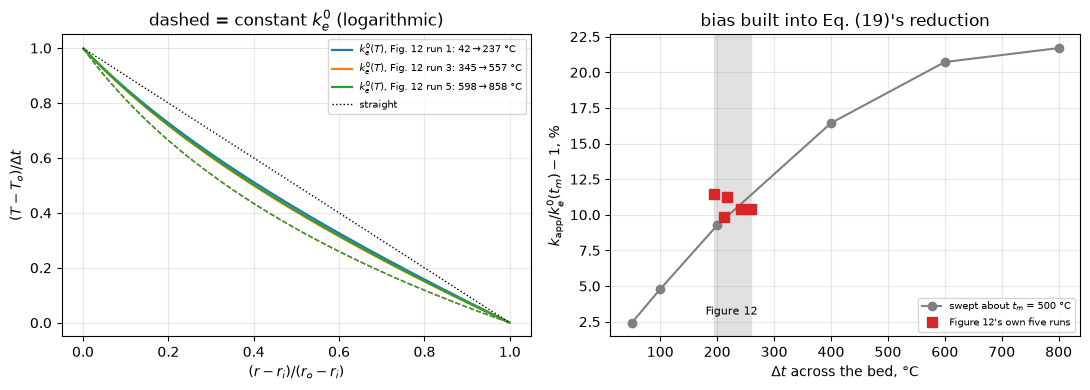

In [28]:
print(f"maximum departure from a straight line, as a fraction of dt:")
print(f"  constant k_e0 (any dt)                     : {red.nonstraight_constK.iloc[0]:.4f}")
for _, r in red12.iterrows():
    print(f"  Eq.(15) k_e0(T), dt = {r.dT:5.0f}  [Figure 12] : {r.nonstraight_varK:.4f}")
for _, r in red.iterrows():
    tag = "" if r.dT <= red12.dT.max() else "  <- beyond Figure 12"
    print(f"  Eq.(15) k_e0(T), dt = {r.dT:5.0f}  [swept]     : {r.nonstraight_varK:.4f}{tag}")
f12_worst = float(red12.nonstraight_varK.max())
print(f"\nAt the drops Figure 12 shows ({red12.dT.min():.0f}-{red12.dT.max():.0f} degC), Eq. (15) "
      f"gives {red12.nonstraight_varK.min():.4f} to {f12_worst:.4f} of dt against\n"
      f"{red.nonstraight_constK.iloc[0]:.4f} for a constant-conductivity bed -- a factor of "
      f"{red.nonstraight_constK.iloc[0] / f12_worst:.1f} to "
      f"{red.nonstraight_constK.iloc[0] / red12.nonstraight_varK.min():.1f} straighter.")
best = red.loc[red.nonstraight_varK.idxmin()]
print(f"The swept minimum is {best.nonstraight_varK:.4f} at dt = {best.dT:.0f} degC -- a factor of "
      f"{red.nonstraight_constK.iloc[0] / best.nonstraight_varK:.1f}, but at a\ncondition Figure 12 "
      f"does not contain. Quoting that factor for this apparatus would be extrapolation.")
METRICS["nonstraightness_constant_k"] = float(red.nonstraight_constK.iloc[0])
METRICS["nonstraightness_varK_swept_min"] = float(red.nonstraight_varK.min())
METRICS["nonstraightness_varK_at_fig12_max"] = f12_worst
METRICS["straightness_factor_at_fig12_min"] = float(red.nonstraight_constK.iloc[0] / f12_worst)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
for k, c in zip((0, 2, 4), ("C0", "C1", "C2")):
    q = red12.iloc[k]
    Ti, To, dT = q.t_in, q.t_out, q.dT
    _, r_c, T, _ = solve_annulus(400, Ti, To, kfun=ke0_iron)
    _, r_cc, Tc_, _ = solve_annulus(400, Ti, To, k_const=1.0)
    x = (r_c - R_I) / (R_O - R_I)
    ax[0].plot(x, (T - To) / dT, c, lw=1.6,
               label=f"$k_e^0(T)$, Fig. 12 run {k + 1}: {To:.0f}$\\to${Ti:.0f} °C")
    ax[0].plot(x, (Tc_ - To) / dT, c, lw=1.0, ls="--")
ax[0].plot([0, 1], [1, 0], "k:", lw=1.0, label="straight")
ax[0].set_xlabel("$(r-r_i)/(r_o-r_i)$"); ax[0].set_ylabel(r"$(T-T_o)/\Delta t$")
ax[0].set_title("dashed = constant $k_e^0$ (logarithmic)"); ax[0].legend(fontsize=7)
ax[1].plot(red.dT, red.bias_pct, "o-", color="0.5", label="swept about $t_m$ = 500 °C")
ax[1].plot(red12.dT, red12.bias_pct, "s", color="C3", ms=7,
           label="Figure 12's own five runs")
ax[1].axvspan(red12.dT.min(), red12.dT.max(), color="0.88", zorder=0)
ax[1].text(red12.dT.mean(), 3, "Figure 12", fontsize=8, ha="center")
ax[1].set_xlabel(r"$\Delta t$ across the bed, °C")
ax[1].set_ylabel(r"$k_{\rm app}/k_e^0(t_m) - 1$, %")
ax[1].set_title("bias built into Eq. (19)'s reduction"); ax[1].legend(fontsize=7)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout(); plt.show()

So the honest reading of the authors' remark is asymmetric, and
narrower than an earlier version of this page claimed:

- **Against a constant conductivity: strong.** A constant-$k_e^0$ annulus at this
  bore ratio departs from a straight line by 13.7 % of the temperature drop, at every
  $\Delta t$. Figure 12's profiles do not look like that, and no reading of the
  figure's abscissa changes it.
- **For Equation (15) specifically: partial.** At the drops Figure 12 shows, Eq. (15)
  brings the departure only down to about 8 % — a factor of **1.7 to 1.9**, not the
  4.5 the swept minimum at $\Delta t = 600$ °C would suggest. Eq. (15)'s profile is still
  visibly bowed. Something makes the real bed straighter than Eq. (15) predicts, and
  this page does not know what.

Quoting 4.5 for this apparatus would be taking the best point of a sweep and
attaching it to a condition the paper never ran — the failure mode this repository
calls out on `F3.5`, of reporting the number that most flatters the conclusion.

### Closing the assertion gap

The break table's `recompute()` was called before these last two cells existed, so its
assertion could only cover the metrics defined at that point. The six defined here are
checked against it now, at the tolerance the rest of the table uses. Without this cell
someone could change `n=400` or the sweep above, the break table would keep sweeping
the old computation, and the published bias metric would no longer belong to the
sweep that guards it.

In [29]:
checked = {k: (METRICS[k], BASE[k]) for k in BASE}
bad = {k: v for k, v in checked.items() if not np.isclose(v[0], v[1], rtol=1e-8, atol=1e-12)}
worst = max(abs(a - b) / max(abs(b), 1e-300) for a, b in checked.values())
print(f"all {len(BASE)} metrics, narrative cells vs recompute(): worst relative difference "
      f"{worst:.2e}")
assert not bad, f"narrative cells disagree with recompute(): {bad}"
assert set(METRICS) == set(BASE), (
    f"reported but not in the break table: {sorted(set(METRICS) - set(BASE))}; "
    f"in the break table but never reported: {sorted(set(BASE) - set(METRICS))}")
print(f"recompute() and the narrative cells agree on all {len(BASE)} published metrics, and the "
      f"two sets are identical -- so no metric escapes the sweep and none is swept but unreported.")

# Grid: the fixed-point loop on the face conductivities is n-limited, not refinable
# without relaxation. Report where it stops converging rather than implying it does not.
for n in (100, 200, 400, 800, 1200):
    try:
        r = reduction_row(float(red12.t_in.iloc[-1]), float(red12.t_out.iloc[-1]), n=n)
        print(f"  n = {n:5d}: bias {r['bias_pct']:.4f} %")
    except AssertionError:
        print(f"  n = {n:5d}: the fixed point does not reach tol in 300 sweeps -- see the note")

all 77 metrics, narrative cells vs recompute(): worst relative difference 1.56e-12
recompute() and the narrative cells agree on all 77 published metrics, and the two sets are identical -- so no metric escapes the sweep and none is swept but unreported.
  n =   100: bias 10.4085 %
  n =   200: bias 10.4072 %
  n =   400: bias 10.4069 %


  n =   800: bias 10.4068 %


  n =  1200: the fixed point does not reach tol in 300 sweeps -- see the note


### Honestly, what is not added

Everything else on this page is reproduction or bookkeeping. The correlation is
not improved, no constant is re-fitted, and no new data are brought to it. The
model is algebra and pymrm is not needed to evaluate it — `nu=1` earns its place
only in the apparatus, which is where the two results above live.

In [30]:
report_agreement("A3.12", METRICS)

Agreement metrics for A3.12:
  eq17_as_printed_over_eq19_ratio                         = 2.001
  eq19_constant_2pi_vs_printed_pct                        = 0.047505
  eq19_constant_exact_ln_vs_printed_pct                   = 0.15995
  table4_ks_over_kg_roundtrip_pct                         = -0.12784
  alpha_beta_ordinary_mean                                = 0.1101
  alpha_beta_ordinary_in_printed_band_frac                = 0.84615
  alpha_beta_ring_over_ordinary_ratio                     = 1.7166
  alpha_beta_theory_over_observed_lower                   = 1.3332
  static_dynamic_crossover_PeM_median                     = 50.5
  table1_vs_table3_exp_max_abs_pct                        = 8.7719
  table1_vs_table3_identical_rows                         = 3
  table1_vs_table3_daggered_rows                          = 5
  paper_calcd_vs_exp_mean_abs_pct                         = 15.32
  paper_calcd_vs_exp_bias_pct                             = -3.4592
  paper_calcd_vs_exp_worst_abs_pct      

{'page': 'A3.12',
 'metrics': {'eq17_as_printed_over_eq19_ratio': 2.000950097804583,
  'eq19_constant_2pi_vs_printed_pct': 0.04750489022915527,
  'eq19_constant_exact_ln_vs_printed_pct': 0.1599536310828542,
  'table4_ks_over_kg_roundtrip_pct': -0.12783636944709853,
  'alpha_beta_ordinary_mean': 0.11010000000000002,
  'alpha_beta_ordinary_in_printed_band_frac': 0.8461538461538461,
  'alpha_beta_ring_over_ordinary_ratio': 1.7166212534059944,
  'alpha_beta_theory_over_observed_lower': 1.3331516802906447,
  'static_dynamic_crossover_PeM_median': 50.5,
  'table1_vs_table3_exp_max_abs_pct': 8.771929824561408,
  'table1_vs_table3_identical_rows': 3.0,
  'table1_vs_table3_daggered_rows': 5.0,
  'paper_calcd_vs_exp_mean_abs_pct': 15.31964684702773,
  'paper_calcd_vs_exp_bias_pct': -3.459182920357257,
  'paper_calcd_vs_exp_worst_abs_pct': 52.0,
  'paper_calcd_vs_exp_mean_abs_pct_no_celite': 13.042475652159943,
  'phi_implied_spread_at_eps040': 7.555738759286603,
  'phi_implied_spread_at_eps040_n

## Reuse

**Use Equation (15) when** you need a stagnant-bed conductivity and you know
$\epsilon$, $D_p$, $k_s$, $k_g$ and can defend a value for $\varphi$. It is
additive, cheap, and its temperature dependence is physically motivated rather than
fitted.

**Before you trust the radiation terms, know what is behind them.** On the only
table of numbers in the paper, the solid-to-solid coefficient $h_{rs}$ is
degenerate with $\varphi$ and can be deleted without changing a single reproduced
value — and the $\varphi$ that absorbs it never leaves Table 4's own printed band,
so the degeneracy is real and not an artefact of a wide search. The void-to-void
coefficient $h_{rv}$ resists deletion on 2 rows of 14. $\gamma$, by contrast, *is*
identifiable: deleting it demands $\varphi$ up to 0.42, twelve of the fourteen rows
above every printed value and two off the top of Figure 9's axis. The
evidence for the radiation mechanism is in Figures 13–17 — a temperature sweep on
one packing at a time, which is exactly what separates a $T^3$ term from a constant
geometric ratio — and this page does not read them. Treat the radiation terms as
*supported by evidence this page has not examined*, not as validated here.

**$\varphi$ is the parameter that will bite you.** It is not measurable
independently, the paper supplies it only as a figure, and at $\epsilon = 0.40$ the
paper's own calculated column implies values spanning a factor of 7.6 — or 2.3 once
the one pathological row (reference 5's 12.7 mm Celite bed, the paper's worst
calculation) is dropped. If you need a number, Table 4's printed pairs — 0.034 at
$\epsilon = 0.40$, 0.040 at 0.43, 0.050 at 0.50, 0.060 at 0.54 — are the defensible
source, and the exponential fit through them reproduces all four to under 3 %.

**For insulating firebrick, use the printed $k_s/k_g$, not the printed $k_s$.**
Table 4 gives that ratio for the firebrick rows and an em dash for every other
packing, and the low-temperature end of Figure 16 shows why: holding $k_s = 0.20$
misses the authors' own curve by 50–61 % there, while holding $k_s/k_g = 4.48$
matches it to a few per cent. Insulating firebrick's conductivity really does climb
with temperature.

**Two printed defects to carry.** Equation (17) is a factor of two low — it prints
$\pi l$ where the cylindrical solution requires $2\pi l$, and the paper's own
Equation (19) proves it. And the Raschig-ring $\gamma$ is printed as
"1.2 mm./9.0 mm. = 0.0134" where the division gives 0.1333; Table 4 carries the
ratio, so the paper's own calculations are unaffected, but using the decimal shifts
$k_e^0/k_g$ by about 9 % at 400 °C.

**Equation (19)'s reduction carries a bias — about +10 % for this apparatus.** The
combination of a temperature-averaged ordinate and a volume-averaged abscissa means
a bed obeying Eq. (15) exactly plots roughly 10 % high at *every* condition Figure 12
shows (195–260 °C across the bed, mean temperatures 110–690 °C). It grows past 20 %
only if $\Delta t$ is pushed to 800 °C, which is about three times anything the paper
ran. If you re-use Figures 13–17 as data, subtract ten per cent; if you run a bed
with a much larger drop, solve the variable-coefficient problem instead — it is the
`solve_annulus` above, and note that its fixed point on the face conductivities is
**n-limited**: it converges up to $n \approx 800$ and stalls at 1200 without
relaxation. The published bias is stable to four digits over $n = 100$–800.

**Structure `S6` relatives.** [`A2.3`](../A2.3-taylor-aris-dispersion/) uses the
same `nu=1` radial operators for Taylor–Aris dispersion; `D1.5` (planned) is the
two-dimensional fixed bed where $k_e$ from this page is the radial coefficient. The
flow term of Eq. (6) is the same lateral-mixing physics `A2.5` treats as axial
dispersion.

**What would unblock the rest of this case.** The *measured points* of Figures 13 to
17, digitised with a maintainer review, would turn the radiation terms from
*unexamined* into *tested* — they are single-packing temperature sweeps, which is
exactly the experiment that breaks the $\varphi$/$h_{rs}$ degeneracy. The theoretical
curves this page does read cannot do that job: they are the model's own output, so
comparing against them tests the transcription, not the physics. Adding the deposited
tabular material
(American Documentation Institute document 5305) would do the same without any
figure work. Ranz's 1952 paper would let Equation (1) be checked against its own
source rather than taken on the authority of this one.

## Reference

Yagi, S., and Kunii, D. (1957). *Studies on effective thermal conductivities in
packed beds.* **AIChE Journal 3**(3), 373–381.
[doi:10.1002/aic.690030317](https://doi.org/10.1002/aic.690030317)

Cited but not consulted: Ranz, W. E. (1952), *Chem. Eng. Progr.* **48**, 247, the
source of Equation (1). Not on disk; nothing about it is stated here beyond what
Yagi & Kunii themselves print.